# Análisis de Experiencia del Cliente — 13/07/2026

## Pregunta de negocio

**¿Existe relación entre el precio de un alojamiento turístico y la satisfacción general de los clientes? ¿Cómo varía esta relación entre ciudades?**

Este notebook analiza la relación entre precio y satisfacción a partir del dataset limpio generado por el equipo. La unidad de análisis es el alojamiento, identificado mediante `apartment_id`.

Aquí solo se validan las variables necesarias y se desarrolla el análisis específico de la pregunta. Los ratings ausentes no se imputan y los resultados se interpretan como **asociaciones**, no como relaciones causales.

## 1. Librerías y configuración visual

Se utilizan `pandas`, `numpy`, `matplotlib`, `scipy` y `statsmodels`.  
La correlación de Spearman describe la relación bruta entre precio y satisfacción; el modelo multivariable permite comprobar si esa relación se mantiene después de controlar diferencias de ciudad, tipo de alojamiento, capacidad, baños, reserva instantánea y año del snapshot.

In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency, mannwhitneyu, norm, spearmanr
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

NAVY = "#1D5273"
TEAL = "#3FA0A9"
DARK = "#2D3439"
YELLOW = "#FFC43D"
LIGHT_YELLOW = "#FFF1BF"
GREY = "#9B9B9B"
LIGHT_GREY = "#E7E7E7"
WHITE = "#FFFFFF"
GRID = "#E2E2E2"
LIGHT_BLUE = "#B9D5E6"
MID_BLUE = "#6FA8C7"
LIGHT_TEAL = "#CFE8E5"
ROW_LIGHT = "#F7F9FA"
ROW_BLUE = "#DCE9F0"

BLUE_CMAP = LinearSegmentedColormap.from_list(
    "stayspain_blues",
    [LIGHT_BLUE, MID_BLUE, NAVY],
)

TITLE_SIZE = 24
AXIS_LABEL_SIZE = 19
TICK_SIZE = 17
LEGEND_SIZE = 16
DATA_LABEL_SIZE = 16

plt.rcParams.update(
    {
        "figure.figsize": (12.5, 7),
        "figure.dpi": 120,
        "figure.facecolor": WHITE,
        "axes.facecolor": WHITE,
        "axes.titlesize": TITLE_SIZE,
        "axes.titleweight": "bold",
        "axes.titlecolor": DARK,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.labelcolor": DARK,
        "axes.edgecolor": GREY,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": TICK_SIZE,
        "ytick.labelsize": TICK_SIZE,
        "xtick.color": DARK,
        "ytick.color": DARK,
        "legend.fontsize": LEGEND_SIZE,
        "legend.title_fontsize": LEGEND_SIZE,
        "grid.color": GRID,
        "grid.alpha": 0.75,
        "font.family": "DejaVu Sans",
    }
)

### 1.1 Funciones auxiliares

Funciones comunes para formatear tablas, ajustar valores p, calcular tamaños del efecto y obtener intervalos de confianza.

In [2]:
def format_es(value, decimals=2, thousands=False):
    """Formatea números con convención española."""

    if pd.isna(value):
        return "—"

    pattern = f"{{:,.{decimals}f}}" if thousands else f"{{:.{decimals}f}}"
    text = pattern.format(value)
    return text.replace(",", "X").replace(".", ",").replace("X", ".")


def p_value_label(p_value):
    """Formatea valores p para la presentación."""

    return "< 0,001" if p_value < 0.001 else format_es(p_value, 3)


def holm_adjust(p_values):
    """Ajusta una familia de valores p mediante el método de Holm."""

    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running_max = 0.0
    total = len(p_values)

    for position, original_index in enumerate(order):
        candidate = (total - position) * p_values[original_index]
        running_max = max(running_max, candidate)
        adjusted[original_index] = min(running_max, 1.0)

    return adjusted


def correlation_label(rho):
    """Clasifica la intensidad absoluta de Spearman."""

    value = abs(rho)
    if value < 0.10:
        return "Muy débil"
    if value < 0.30:
        return "Débil"
    if value < 0.50:
        return "Moderada"
    return "Fuerte"


def effect_label(delta):
    """Clasifica la magnitud absoluta del delta de Cliff."""

    value = abs(delta)
    if value < 0.147:
        return "Despreciable"
    if value < 0.330:
        return "Pequeño"
    if value < 0.474:
        return "Moderado"
    return "Grande"


def bootstrap_spearman(x, y, n_boot=1000, seed=42):
    """Calcula un intervalo bootstrap del 95 % para Spearman."""

    x = np.asarray(x)
    y = np.asarray(y)
    rng = np.random.default_rng(seed)
    values = np.empty(n_boot)
    n = len(x)

    for i in range(n_boot):
        index = rng.integers(0, n, n)
        values[i] = spearmanr(x[index], y[index]).statistic

    return np.quantile(values, [0.025, 0.975])


def mann_whitney_effect(high_values, low_values):
    """Calcula Mann–Whitney U, valor p y delta de Cliff."""

    u_statistic, p_value = mannwhitneyu(
        high_values,
        low_values,
        alternative="two-sided",
        method="asymptotic",
    )
    cliff_delta = (
        2 * u_statistic / (len(high_values) * len(low_values)) - 1
    )
    return u_statistic, p_value, cliff_delta


def cramers_v(table):
    """Calcula Cramér's V a partir de una tabla de contingencia."""

    chi2, p_value, _, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    denominator = min(table.shape[0] - 1, table.shape[1] - 1)
    value = np.sqrt((chi2 / n) / denominator)
    return chi2, p_value, value


def quantile_groups(series, q, labels=None):
    """Crea grupos cuantiles sin separar artificialmente precios iguales."""

    return pd.qcut(
        series,
        q=q,
        labels=labels,
        duplicates="drop",
    )


def graphic_table(
    dataframe,
    title,
    formats=None,
    highlight_max=None,
    highlight_min=None,
    width=None,
    font_size=None,
    column_widths=None,
):
    """Muestra una tabla gráfica con el estilo visual del equipo."""

    numeric_data = dataframe.reset_index(drop=True).copy()
    data = numeric_data.copy()
    formats = formats or {}
    highlight_max = highlight_max or []
    highlight_min = highlight_min or []

    for column, format_text in formats.items():
        if column not in data.columns:
            continue
        data[column] = data[column].map(
            lambda value: (
                format_text.format(value)
                .replace(",", "X")
                .replace(".", ",")
                .replace("X", ".")
                if pd.notna(value)
                else "—"
            )
        )

    rows, columns = data.shape
    automatic_size = 16 if columns <= 4 else 14.5 if columns <= 7 else 13.5
    body_size = automatic_size if font_size is None else float(font_size)
    header_size = body_size + 1
    width = width or max(9.5, columns * 1.85)
    height = max(3.0, rows * 0.58 + 1.5)

    fig, ax = plt.subplots(figsize=(width, height), dpi=120)
    ax.axis("off")

    table = ax.table(
        cellText=data.values,
        colLabels=data.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=column_widths,
        bbox=[0, 0.03, 1, 0.84],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(body_size)

    row_height = 0.84 / (rows + 1)
    for (row, column), cell in table.get_celld().items():
        cell.set_edgecolor(WHITE)
        cell.set_linewidth(1.2)
        cell.set_height(row_height)
        cell.PAD = 0.06
        cell.get_text().set_wrap(True)

        if row == 0:
            cell.set_facecolor(NAVY)
            cell.set_text_props(
                color=WHITE,
                weight="bold",
                fontsize=header_size,
            )
        else:
            cell.set_facecolor(ROW_LIGHT if row % 2 else ROW_BLUE)
            cell.set_text_props(color=DARK, fontsize=body_size)

    def highlight(columns_to_highlight, mode, facecolor):
        for column_name in columns_to_highlight:
            if column_name not in numeric_data.columns:
                continue
            values = pd.to_numeric(numeric_data[column_name], errors="coerce")
            if not values.notna().any():
                continue
            row_position = int(getattr(values, mode)()) + 1
            column_position = data.columns.get_loc(column_name)
            selected_cell = table[(row_position, column_position)]
            selected_cell.set_facecolor(facecolor)
            selected_cell.set_text_props(color=DARK, weight="bold")

    highlight(highlight_max, "idxmax", LIGHT_TEAL)
    highlight(highlight_min, "idxmin", LIGHT_YELLOW)

    ax.set_title(
        title,
        fontsize=TITLE_SIZE,
        fontweight="bold",
        color=DARK,
        pad=4,
        y=0.93,
    )
    plt.subplots_adjust(top=0.98, bottom=0.02, left=0.02, right=0.98)
    plt.show()

## 2. Carga y validación del dataset

Se carga el dataset limpio generado por el equipo. No se repite la limpieza general.

En este notebook solo se comprueba:

- Que estén disponibles las variables necesarias.
- Que exista una sola fila por `apartment_id`.
- Que el precio sea positivo y el rating esté dentro del rango esperado.
- Que `logp` sea coherente con el logaritmo del precio.
- Que la fecha del snapshot pueda utilizarse en la revisión temporal.

In [3]:
def find_dataset():
    """Localiza el dataset limpio desde la raíz, Data o Scripts."""

    current = Path.cwd()
    name = "clean_dataset_13_07_2026.csv"
    candidates = [
        current / "Data" / name,
        current.parent / "Data" / name,
        current / name,
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError("No se encontró el dataset limpio.")


DATASET_PATH = find_dataset()
df = pd.read_csv(DATASET_PATH)

print("Dataset cargado:", DATASET_PATH.name)
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Dataset cargado: clean_dataset_13_07_2026.csv
Filas: 9650
Columnas: 54


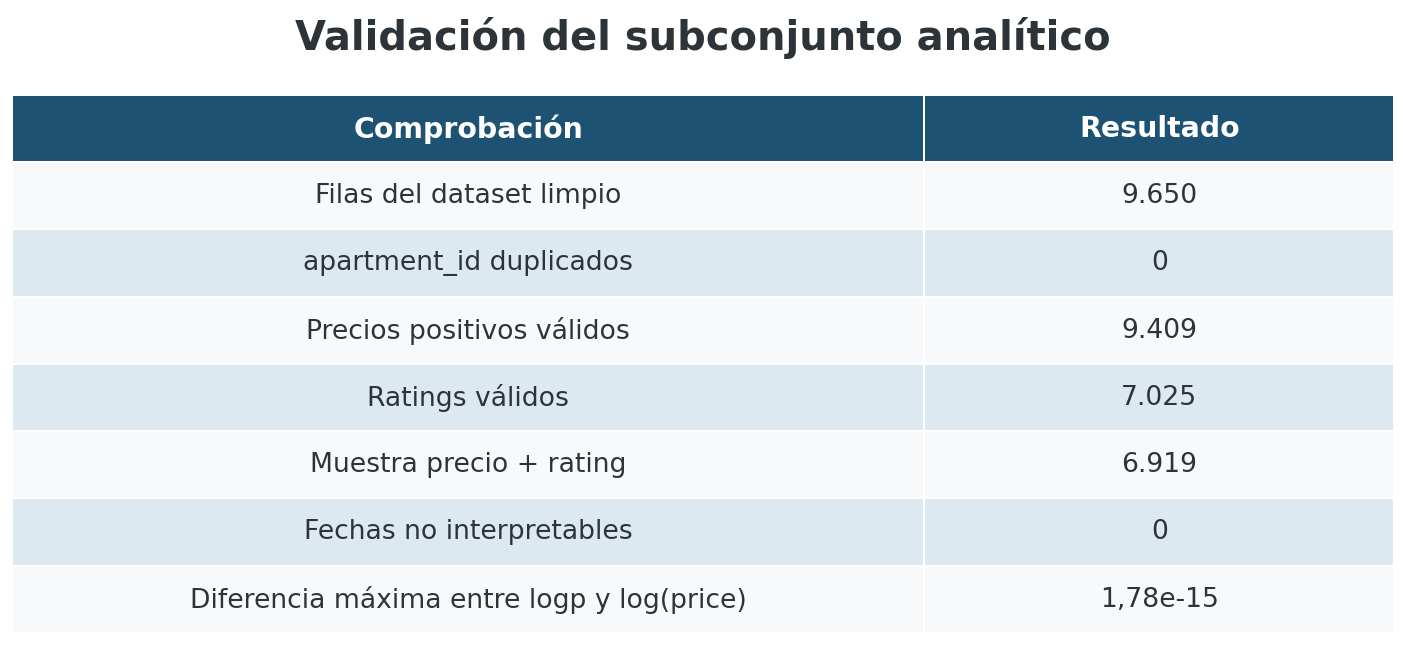

In [4]:
REQUIRED_COLUMNS = [
    "apartment_id",
    "city",
    "price_€",
    "logp",
    "review_scores_rating",
    "number_of_reviews",
    "insert_date",
    "room_type",
    "accommodates",
    "bathrooms",
    "is_instant_bookable_numeric",
]

missing_columns = [
    column for column in REQUIRED_COLUMNS if column not in df.columns
]
if missing_columns:
    raise ValueError(f"Faltan columnas necesarias: {missing_columns}")

# Validaciones específicas del análisis.
df["insert_date_parsed"] = pd.to_datetime(
    df["insert_date"],
    errors="coerce",
)
df["snapshot_year"] = df["insert_date_parsed"].dt.year
df["has_valid_price"] = df["price_€"].notna() & (df["price_€"] > 0)
df["has_valid_rating"] = df["review_scores_rating"].between(0, 100)
df["analytic"] = df["has_valid_price"] & df["has_valid_rating"]

logp_difference = (
    df.loc[df["has_valid_price"], "logp"]
    - np.log(df.loc[df["has_valid_price"], "price_€"])
).abs().max()

validation_summary = pd.DataFrame(
    {
        "Comprobación": [
            "Filas del dataset limpio",
            "apartment_id duplicados",
            "Precios positivos válidos",
            "Ratings válidos",
            "Muestra precio + rating",
            "Fechas no interpretables",
            "Diferencia máxima entre logp y log(price)",
        ],
        "Resultado": [
            format_es(len(df), 0, thousands=True),
            format_es(df["apartment_id"].duplicated().sum(), 0, thousands=True),
            format_es(df["has_valid_price"].sum(), 0, thousands=True),
            format_es(df["has_valid_rating"].sum(), 0, thousands=True),
            format_es(df["analytic"].sum(), 0, thousands=True),
            format_es(df["insert_date_parsed"].isna().sum(), 0, thousands=True),
            f"{logp_difference:.2e}".replace(".", ","),
        ],
    }
)

graphic_table(
    validation_summary,
    "Validación del subconjunto analítico",
    width=12,
    column_widths=[0.66, 0.34],
)

### Interpretación

El dataset limpio contiene **9.650 alojamientos únicos** y no presenta duplicados de `apartment_id`.  
Se dispone de precio positivo para **9.409 alojamientos**, rating válido para **7.025** y una muestra analítica conjunta de **6.919 casos (71,7 %)**.

La diferencia entre `logp` y `log(price_€)` es prácticamente nula, por lo que la transformación logarítmica es coherente. Los ratings ausentes no se imputan: el análisis representa únicamente a los alojamientos con precio y valoración disponibles.

## 3. Preguntas analíticas y lógica del análisis

La pregunta de negocio se divide en cinco pasos:

1. **¿La muestra con rating representa de forma similar a las ciudades y niveles de precio?**
2. **¿Existe una relación bruta entre precio y satisfacción?**
3. **¿Cómo cambia esa relación entre ciudades?**
4. **¿Se mantiene después de controlar otras características del alojamiento?**
5. **¿La diferencia entre alojamientos económicos y caros tiene relevancia práctica?**

La estrategia combina revisión de cobertura y sesgos, Spearman global y por ciudad, regresión múltiple con errores robustos HC3 e interacción precio × ciudad, robustez mediante el volumen de reseñas, comparación Q1–Q4 y análisis de sensibilidad.

## 4. Validez de la muestra y posibles sesgos

Antes de responder a la pregunta principal se revisa qué parte de la oferta dispone de precio y valoración.

Las comprobaciones principales son:

- Cobertura de la muestra analítica por ciudad.
- Cobertura de rating en los cuartiles de precio de cada ciudad.
- Diferencia de precio entre alojamientos con y sin rating.
- Asociación entre la disponibilidad de rating y la ciudad o el nivel de precio.

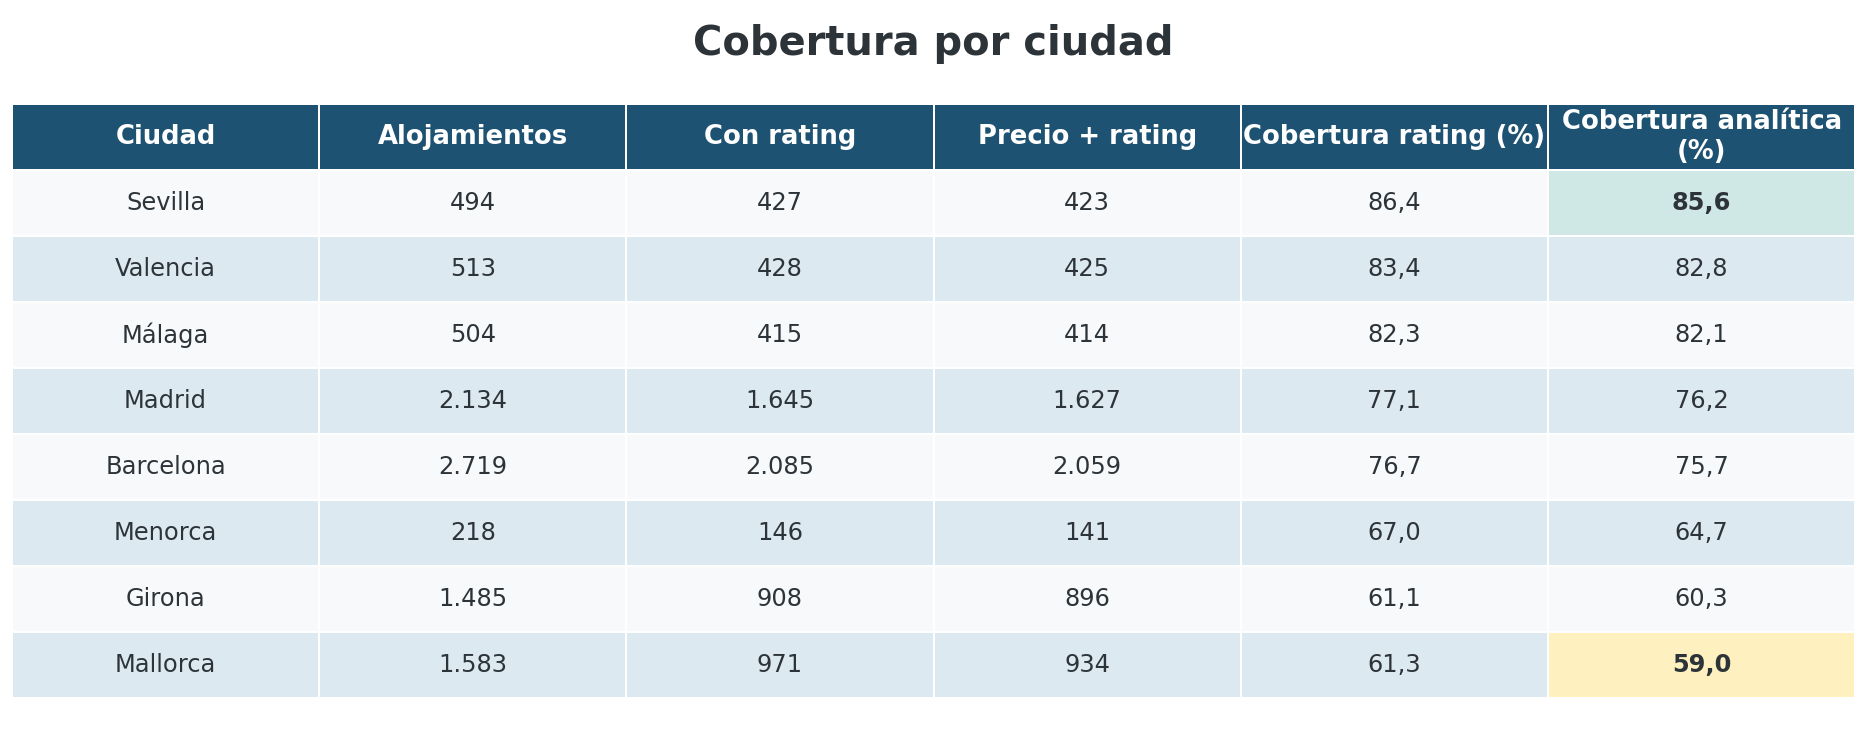

In [5]:
coverage_city = (
    df.groupby("city")
    .agg(
        Alojamientos=("apartment_id", "size"),
        Con_rating=("has_valid_rating", "sum"),
        Muestra_analitica=("analytic", "sum"),
    )
    .reset_index()
)
coverage_city["Cobertura_rating_%"] = (
    coverage_city["Con_rating"] / coverage_city["Alojamientos"] * 100
)
coverage_city["Cobertura_analitica_%"] = (
    coverage_city["Muestra_analitica"]
    / coverage_city["Alojamientos"]
    * 100
)
coverage_city = coverage_city.sort_values(
    "Cobertura_analitica_%",
    ascending=False,
)

coverage_table = coverage_city.rename(
    columns={
        "city": "Ciudad",
        "Con_rating": "Con rating",
        "Muestra_analitica": "Precio + rating",
        "Cobertura_rating_%": "Cobertura rating (%)",
        "Cobertura_analitica_%": "Cobertura analítica (%)",
    }
)[
    [
        "Ciudad",
        "Alojamientos",
        "Con rating",
        "Precio + rating",
        "Cobertura rating (%)",
        "Cobertura analítica (%)",
    ]
]

graphic_table(
    coverage_table,
    "Cobertura por ciudad",
    formats={
        "Alojamientos": "{:,.0f}",
        "Con rating": "{:,.0f}",
        "Precio + rating": "{:,.0f}",
        "Cobertura rating (%)": "{:.1f}",
        "Cobertura analítica (%)": "{:.1f}",
    },
    highlight_max=["Cobertura analítica (%)"],
    highlight_min=["Cobertura analítica (%)"],
    width=16,
)

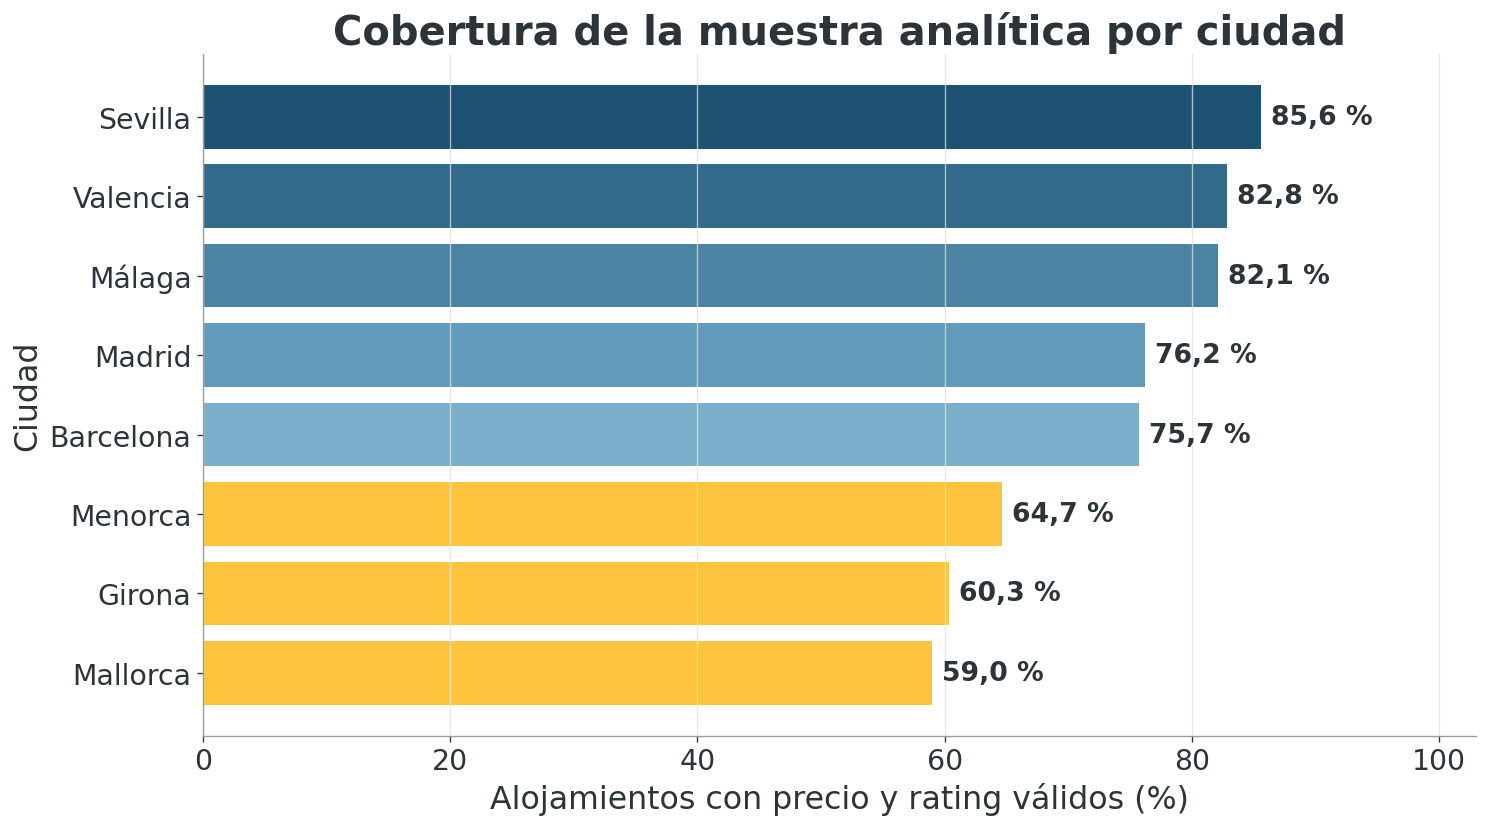

In [6]:
coverage_plot = coverage_city.sort_values(
    "Cobertura_analitica_%",
    ascending=True,
).copy()

colors = [
    YELLOW if value < 70 else BLUE_CMAP(i / max(len(coverage_plot) - 1, 1))
    for i, value in enumerate(coverage_plot["Cobertura_analitica_%"])
]

fig, ax = plt.subplots(figsize=(12.5, 7))
bars = ax.barh(
    coverage_plot["city"],
    coverage_plot["Cobertura_analitica_%"],
    color=colors,
)

for bar, value in zip(bars, coverage_plot["Cobertura_analitica_%"]):
    ax.text(
        value + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{format_es(value, 1)} %",
        va="center",
        fontsize=DATA_LABEL_SIZE,
        color=DARK,
        fontweight="bold",
    )

ax.set(
    title="Cobertura de la muestra analítica por ciudad",
    xlabel="Alojamientos con precio y rating válidos (%)",
    ylabel="Ciudad",
    xlim=(0, 103),
)
ax.grid(axis="x")
plt.tight_layout()
plt.show()

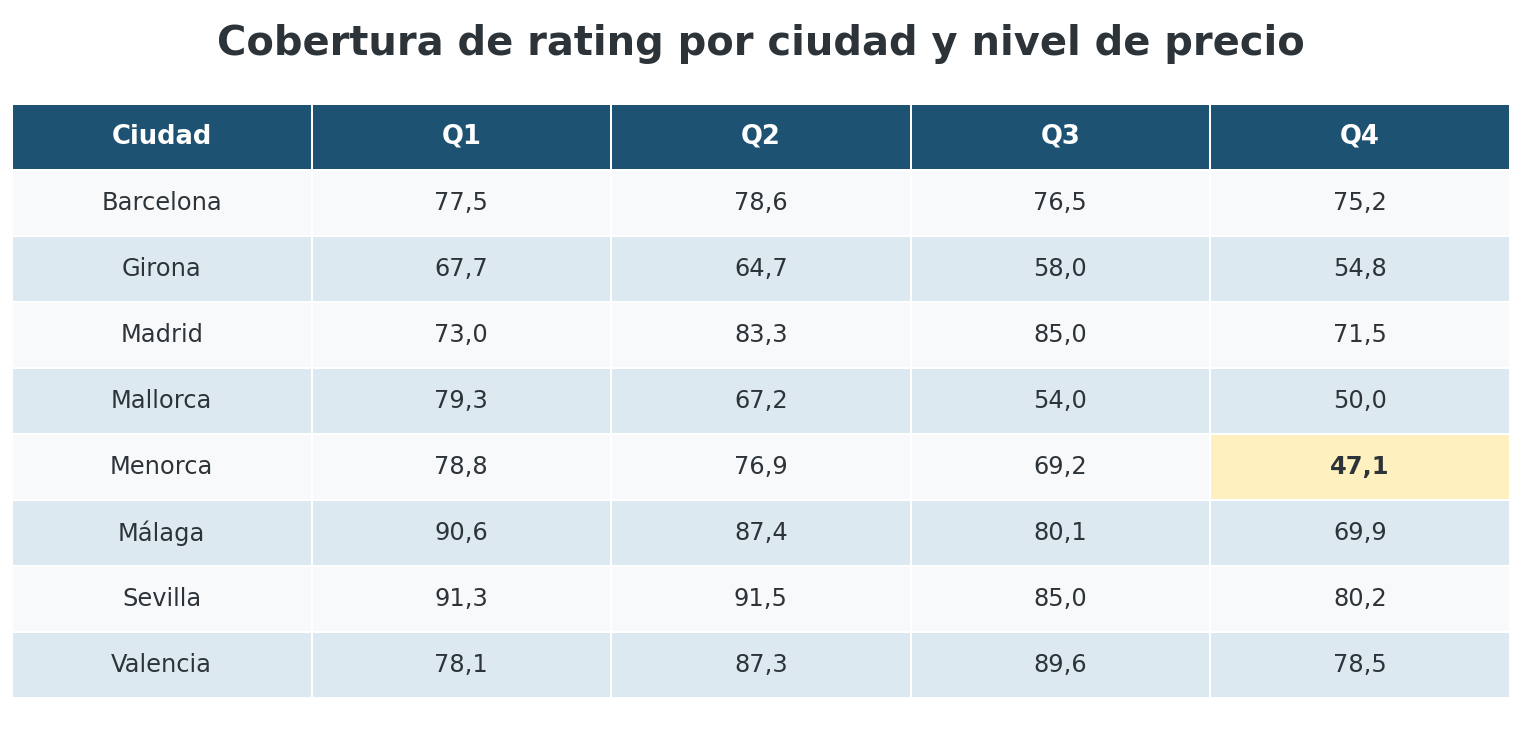

In [7]:
price_valid = df.loc[df["has_valid_price"]].copy()
price_valid["Cuartil de precio"] = price_valid.groupby("city")[
    "price_€"
].transform(
    lambda series: quantile_groups(
        series,
        4,
        labels=["Q1", "Q2", "Q3", "Q4"],
    )
)

coverage_price = (
    price_valid.groupby(
        ["city", "Cuartil de precio"],
        observed=False,
    )
    .agg(
        Alojamientos=("apartment_id", "size"),
        Con_rating=("has_valid_rating", "sum"),
    )
    .reset_index()
)
coverage_price["Cobertura (%)"] = (
    coverage_price["Con_rating"]
    / coverage_price["Alojamientos"]
    * 100
)

coverage_matrix = (
    coverage_price.pivot(
        index="city",
        columns="Cuartil de precio",
        values="Cobertura (%)",
    )
    .reset_index()
    .rename(columns={"city": "Ciudad"})
)

graphic_table(
    coverage_matrix,
    "Cobertura de rating por ciudad y nivel de precio",
    formats={quartile: "{:.1f}" for quartile in ["Q1", "Q2", "Q3", "Q4"]},
    highlight_min=["Q4"],
    width=13,
)

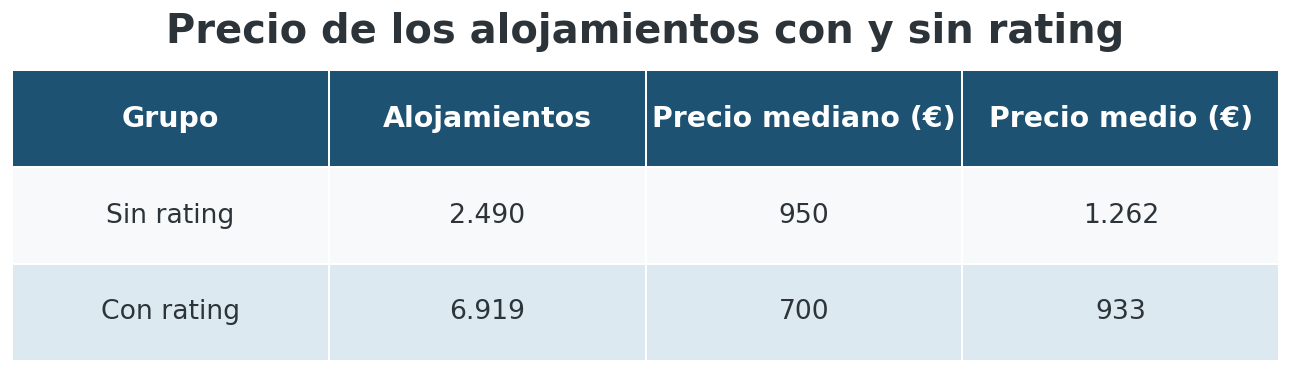

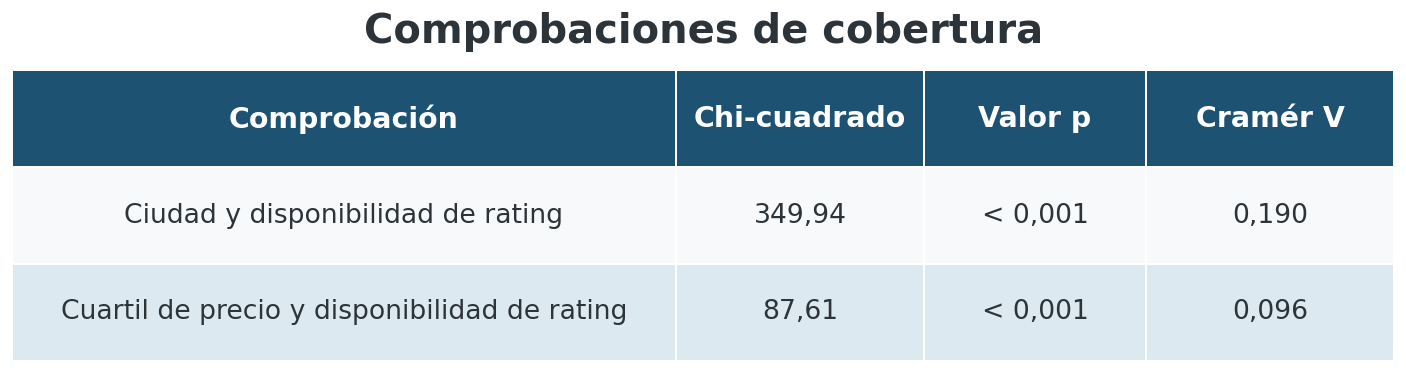

In [8]:
price_rating_profile = (
    price_valid.groupby("has_valid_rating")["price_€"]
    .agg(["count", "median", "mean"])
    .reset_index()
)
price_rating_profile["has_valid_rating"] = price_rating_profile[
    "has_valid_rating"
].map({True: "Con rating", False: "Sin rating"})
price_rating_profile = price_rating_profile.rename(
    columns={
        "has_valid_rating": "Grupo",
        "count": "Alojamientos",
        "median": "Precio mediano (€)",
        "mean": "Precio medio (€)",
    }
)

city_table = pd.crosstab(df["city"], df["has_valid_rating"])
city_chi2, city_p, city_v = cramers_v(city_table)

quartile_table = pd.crosstab(
    price_valid["Cuartil de precio"],
    price_valid["has_valid_rating"],
)
quartile_chi2, quartile_p, quartile_v = cramers_v(quartile_table)

bias_tests = pd.DataFrame(
    {
        "Comprobación": [
            "Ciudad y disponibilidad de rating",
            "Cuartil de precio y disponibilidad de rating",
        ],
        "Chi-cuadrado": [city_chi2, quartile_chi2],
        "Valor p": [city_p, quartile_p],
        "Cramér V": [city_v, quartile_v],
    }
)

graphic_table(
    price_rating_profile,
    "Precio de los alojamientos con y sin rating",
    formats={
        "Alojamientos": "{:,.0f}",
        "Precio mediano (€)": "{:,.0f}",
        "Precio medio (€)": "{:,.0f}",
    },
    width=11,
)

bias_tests_table = bias_tests.copy()
bias_tests_table["Valor p"] = bias_tests_table[
    "Valor p"
].map(p_value_label)

graphic_table(
    bias_tests_table,
    "Comprobaciones de cobertura",
    formats={
        "Chi-cuadrado": "{:.2f}",
        "Cramér V": "{:.3f}",
    },
    width=12,
    column_widths=[0.48, 0.18, 0.16, 0.18],
)

### Interpretación

La cobertura no es homogénea entre ciudades. Los valores más altos aparecen en **Sevilla (85,6 %)**, **Valencia (82,8 %)** y **Málaga (82,1 %)**; los más bajos en **Mallorca (59,0 %)** y **Girona (60,3 %)**.

Además, los alojamientos sin rating tienen un precio mediano superior (**950 €**) al de los alojamientos con rating (**700 €**). Esto indica que la ausencia de valoraciones no es completamente aleatoria y puede afectar especialmente a la interpretación de los segmentos de precio alto.

Por tanto, Mallorca y Girona pueden ofrecer señales interesantes, pero sus resultados deben interpretarse con mayor cautela por su menor cobertura.

La disponibilidad de rating también se asocia con la ciudad (**Cramér V = 0,190**) y, en menor medida, con el cuartil de precio (**Cramér V = 0,096**). Esto indica que el posible sesgo de cobertura tiene principalmente una dimensión geográfica, mientras que la asociación con el nivel de precio es más débil.

## 5. Relación global entre precio y satisfacción

### Hipótesis

- **H₀:** no existe una relación monotónica entre precio y satisfacción general (`ρ = 0`).
- **H₁:** existe una relación monotónica entre precio y satisfacción general (`ρ ≠ 0`).

Se utiliza Spearman porque trabaja con rangos y es menos sensible que Pearson a la asimetría y a los valores extremos del precio.

`logp` se utiliza solo para representar mejor el eje del precio. Como es una transformación monotónica, no cambia el orden de los alojamientos ni la correlación de Spearman.

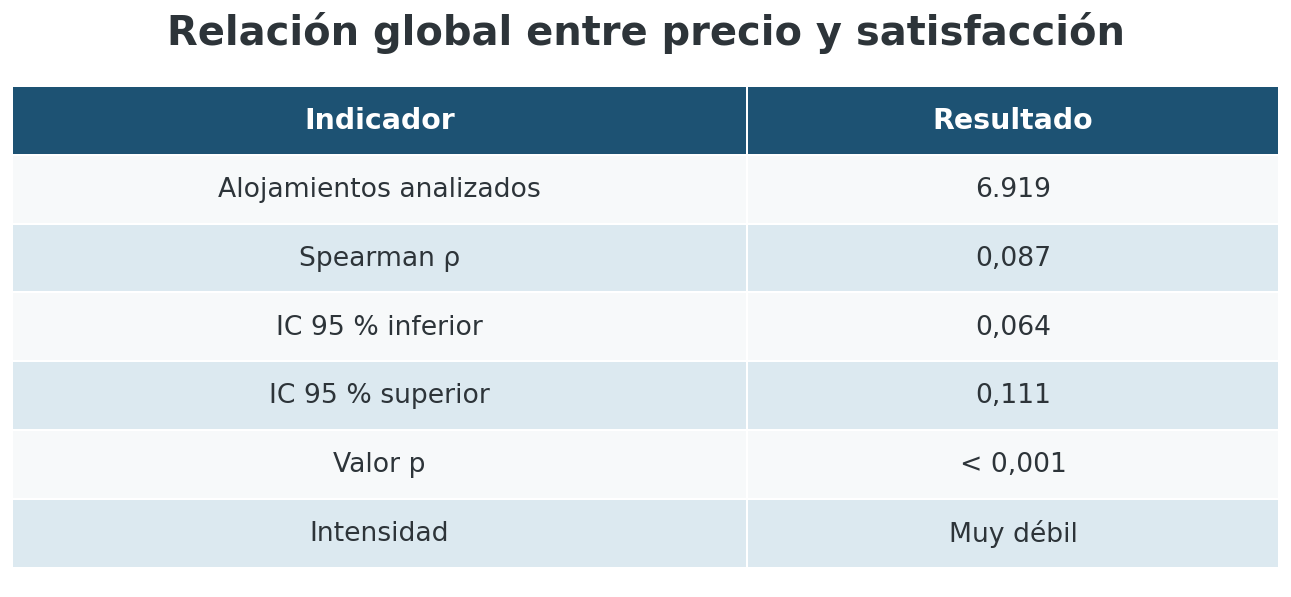

In [9]:
df_analysis = df.loc[df["analytic"]].copy()

rho_global, p_global = spearmanr(
    df_analysis["price_€"],
    df_analysis["review_scores_rating"],
)
ci_global = bootstrap_spearman(
    df_analysis["price_€"],
    df_analysis["review_scores_rating"],
    n_boot=1000,
    seed=42,
)

df_analysis["Decil de precio"] = (
    quantile_groups(
        df_analysis["price_€"],
        10,
        labels=False,
    )
    + 1
)

decile_summary = (
    df_analysis.groupby("Decil de precio")
    .agg(
        Precio_mediano=("price_€", "median"),
        Rating_mediano=("review_scores_rating", "median"),
        
    )
    .reset_index()
)

global_result = pd.DataFrame(
    {
        "Indicador": [
            "Alojamientos analizados",
            "Spearman ρ",
            "IC 95 % inferior",
            "IC 95 % superior",
            "Valor p",
            "Intensidad",
        ],
        "Resultado": [
            format_es(len(df_analysis), 0, thousands=True),
            format_es(rho_global, 3),
            format_es(ci_global[0], 3),
            format_es(ci_global[1], 3),
            p_value_label(p_global),
            correlation_label(rho_global),
        ],
    }
)

graphic_table(
    global_result,
    "Relación global entre precio y satisfacción",
    width=11,
    column_widths=[0.58, 0.42],
)

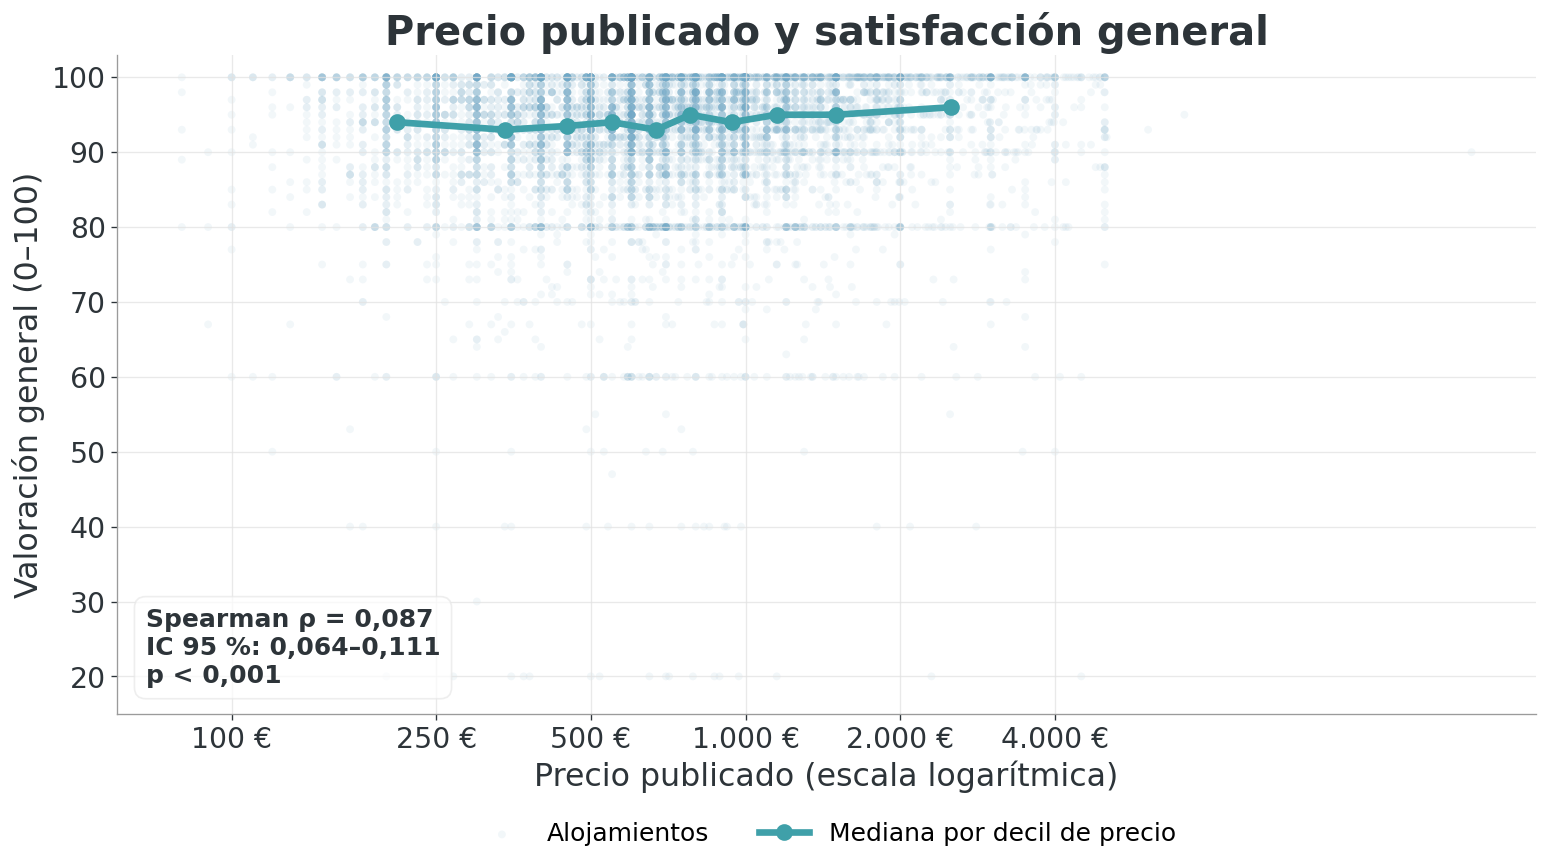

In [10]:
fig, ax = plt.subplots(figsize=(13, 7.5))

ax.scatter(
    df_analysis["logp"],
    df_analysis["review_scores_rating"],
    s=22,
    alpha=0.09,
    color=MID_BLUE,
    edgecolors="none",
    label="Alojamientos",
)

ax.plot(
    np.log(decile_summary["Precio_mediano"]),
    decile_summary["Rating_mediano"],
    color= TEAL,
    marker="o",
    linewidth=4,
    markersize=9
    ,
    label="Mediana por decil de precio",
)

price_ticks = np.array([100, 250, 500, 1000, 2000, 4000])
ax.set_xticks(np.log(price_ticks))
ax.set_xticklabels([f"{value:,.0f} €".replace(",", ".") for value in price_ticks])

ax.set(
    title="Precio publicado y satisfacción general",
    xlabel="Precio publicado (escala logarítmica)",
    ylabel="Valoración general (0–100)",
    ylim=(15, 103),
)
ax.grid(axis="both")
ax.legend(loc="upper center",bbox_to_anchor=(0.5, -0.13),ncol=2,frameon=False,fontsize=15,
)

ax.text(
    0.02,
    0.04,
    f"Spearman ρ = {format_es(rho_global, 3)}\n"
    f"IC 95 %: {format_es(ci_global[0], 3)}–{format_es(ci_global[1], 3)}\n"
    f"p {p_value_label(p_global)}",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
    verticalalignment="bottom",
    color=DARK,
    bbox={
        "boxstyle": "round,pad=0.45",
        "facecolor": WHITE,
        "edgecolor": LIGHT_GREY,
        "alpha": 0.7,
    },
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
plt.show()

### Interpretación

En el conjunto de **6.919 alojamientos**, la relación entre precio y satisfacción es **positiva pero muy débil**:

- **Spearman ρ = 0,087**
- **p < 0,001**
- intervalo bootstrap del 95 % aproximadamente entre **0,064 y 0,111**

La significación estadística se explica en parte por el tamaño de la muestra. La magnitud es pequeña: **un precio más alto no garantiza una mayor satisfacción general**.

## 6. ¿Cómo varía la relación entre ciudades?

Se estima la correlación de Spearman por ciudad, junto con su intervalo de confianza bootstrap del 95 % y el valor p ajustado mediante Holm.

La interpretación prioriza la magnitud del coeficiente y su intervalo de confianza, no únicamente la significación estadística.

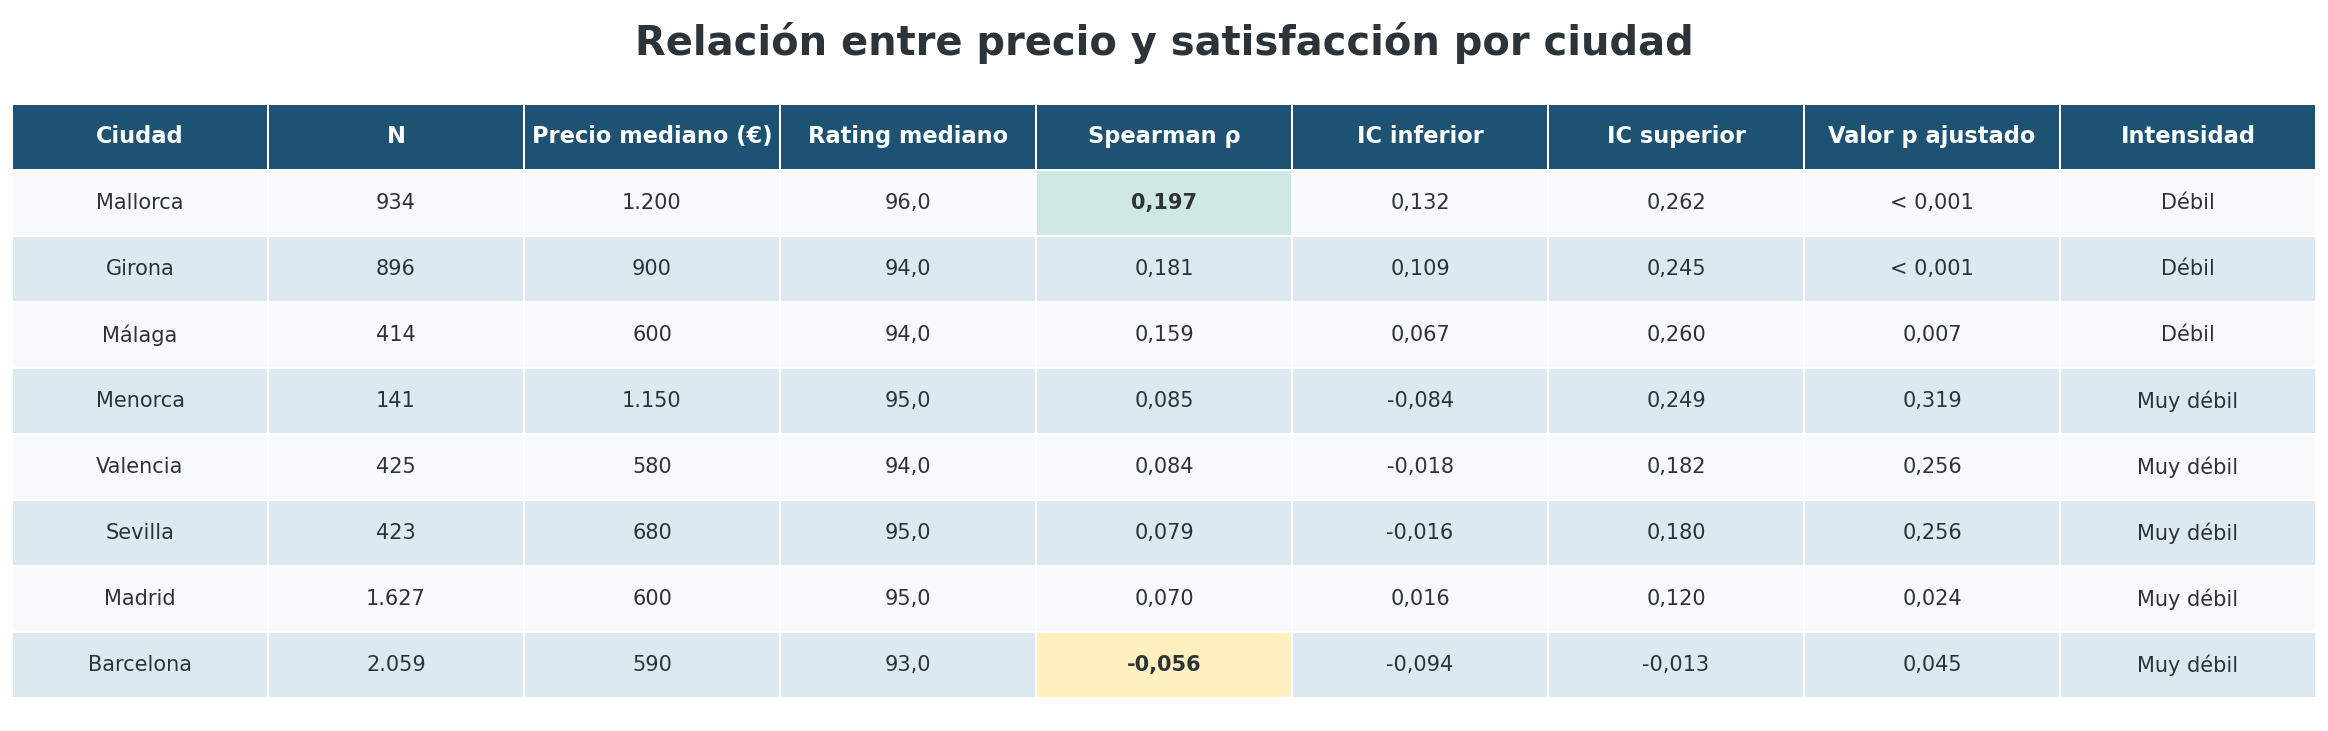

In [11]:
city_rows = []

for position, (city, city_data) in enumerate(
    df_analysis.groupby("city")
):
    rho, p_value = spearmanr(
        city_data["price_€"],
        city_data["review_scores_rating"],
    )
    ci = bootstrap_spearman(
        city_data["price_€"],
        city_data["review_scores_rating"],
        n_boot=1000,
        seed=100 + position,
    )

    city_rows.append(
        {
            "Ciudad": city,
            "N": len(city_data),
            "Precio mediano (€)": city_data["price_€"].median(),
            "Rating mediano": city_data["review_scores_rating"].median(),
            "Spearman ρ": rho,
            "IC inferior": ci[0],
            "IC superior": ci[1],
            "Valor p": p_value,
            "Intensidad": correlation_label(rho),
        }
    )

city_results = pd.DataFrame(city_rows)
city_results["Valor p ajustado"] = holm_adjust(city_results["Valor p"])

city_results = city_results.sort_values(
    "Spearman ρ",
    ascending=False,
).reset_index(drop=True)

city_table = city_results[
    [
        "Ciudad",
        "N",
        "Precio mediano (€)",
        "Rating mediano",
        "Spearman ρ",
        "IC inferior",
        "IC superior",
        "Valor p ajustado",
        "Intensidad",
    ]
].copy()
city_table["Valor p ajustado"] = city_table[
    "Valor p ajustado"
].map(p_value_label)

graphic_table(
    city_table,
    "Relación entre precio y satisfacción por ciudad",
    formats={
        "N": "{:,.0f}",
        "Precio mediano (€)": "{:,.0f}",
        "Rating mediano": "{:.1f}",
        "Spearman ρ": "{:.3f}",
        "IC inferior": "{:.3f}",
        "IC superior": "{:.3f}",
    },
    highlight_max=["Spearman ρ"],
    highlight_min=["Spearman ρ"],
    width=20,
    font_size=12.5,
)

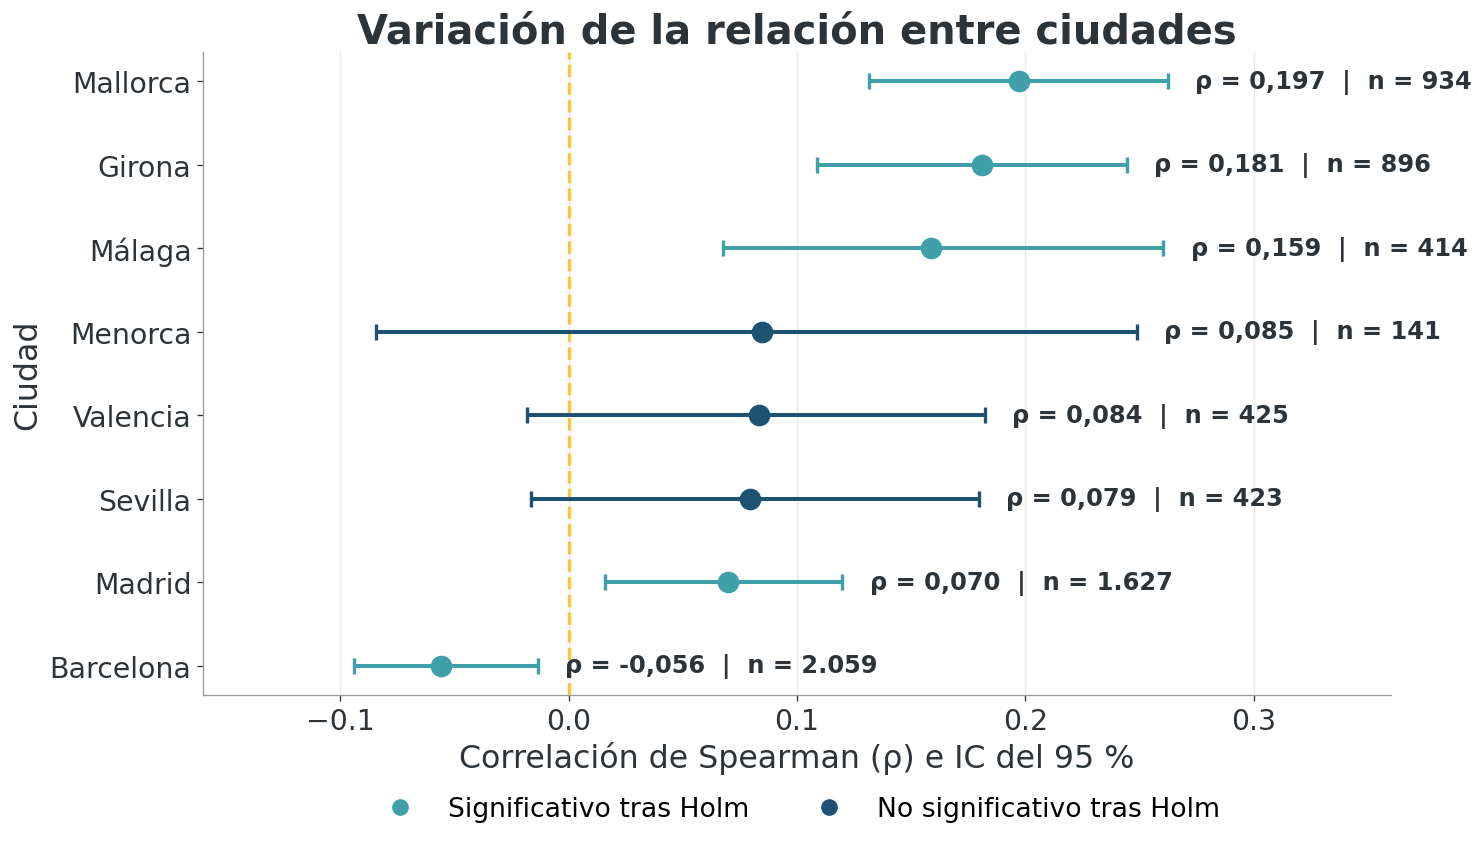

In [12]:
forest = city_results.sort_values("Spearman ρ").copy()
y_positions = np.arange(len(forest))

fig, ax = plt.subplots(figsize=(12.5, 7.5))

for y, (_, row) in zip(y_positions, forest.iterrows()):
    color = TEAL if row["Valor p ajustado"] < 0.05 else NAVY
    ax.errorbar(
        row["Spearman ρ"],
        y,
        xerr=[
            [row["Spearman ρ"] - row["IC inferior"]],
            [row["IC superior"] - row["Spearman ρ"]],
        ],
        fmt="o",color=color,ecolor=color,markerfacecolor=color,markeredgecolor=color,
        markeredgewidth=2,markersize=11,capsize=5,linewidth=2.4,zorder=3,
    )
    n_text = f"{int(row['N']):,}".replace(",", ".")
    ax.text(
    row["IC superior"] + 0.012,
    y,
    f"ρ = {format_es(row['Spearman ρ'], 3)}  |  n = {n_text}",
    va="center",fontsize=14.5,fontweight="bold",color=DARK,
)

ax.axvline(0, color=YELLOW, linestyle="--", linewidth=2)
ax.set_yticks(y_positions)
ax.set_yticklabels(forest["Ciudad"])
ax.set(
    title="Variación de la relación entre ciudades",xlabel="Correlación de Spearman (ρ) e IC del 95 %",
    ylabel="Ciudad",xlim=(-0.16, 0.36),
)
ax.grid(axis="x")

legend_handles = [
    Line2D(
        [0],[0],marker="o",color=TEAL,linestyle="none",markersize=9,label="Significativo tras Holm",
    ),
    Line2D(
        [0],[0],marker="o",color=NAVY,linestyle="none",markersize=9,label="No significativo tras Holm",
    ),
]
ax.legend(
    handles=legend_handles,frameon=False,loc="upper center",bbox_to_anchor=(0.5, -0.12),ncol=2,
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.show()

### Interpretación

La relación entre precio y satisfacción no presenta el mismo patrón en todas las ciudades.

Las asociaciones positivas más claras aparecen en **Mallorca (ρ = 0,197)**, **Girona (ρ = 0,181)** y **Málaga (ρ = 0,159)**. Estas relaciones siguen siendo débiles, aunque permanecen estadísticamente significativas después de la corrección de Holm.

**Madrid** también presenta una asociación positiva significativa, pero de magnitud muy débil (**ρ = 0,070**).

En **Barcelona**, la asociación es ligeramente negativa (**ρ = −0,056**) y resulta estadísticamente significativa después del ajuste por comparaciones múltiples (**p ajustado = 0,045**). Sin embargo, su magnitud sigue siendo muy débil.

Por tanto, la relación entre precio y satisfacción varía entre ciudades, pero su intensidad es baja en todos los casos.

## 7. Modelo multivariable: relación ajustada

La correlación de Spearman muestra la asociación bruta, pero no controla que los alojamientos caros puedan diferir también en tipo, capacidad, número de baños, facilidad de reserva o año del dato.

Se estima una **regresión lineal múltiple explicativa**:

\[
\text{rating} =
\beta_0 +
\beta_1 \log(\text{precio}) +
\text{ciudad} +
\log(\text{precio}) \times \text{ciudad} +
\text{variables de control}
\]

Controles incluidos:

- tipo de alojamiento;
- capacidad (`accommodates`);
- baños;
- reserva instantánea;
- año del snapshot.

El modelo se estima sobre **6.877 casos completos**. La diferencia respecto a los **6.919 alojamientos** de la muestra analítica se debe a 42 registros con valores ausentes en alguna de las variables de control.

La interacción `logp × ciudad` permite comprobar si la relación ajustada entre precio y satisfacción cambia entre ciudades. Se utilizan errores estándar robustos **HC3**. El objetivo es explicar asociaciones ajustadas, no predecir ni demostrar causalidad.

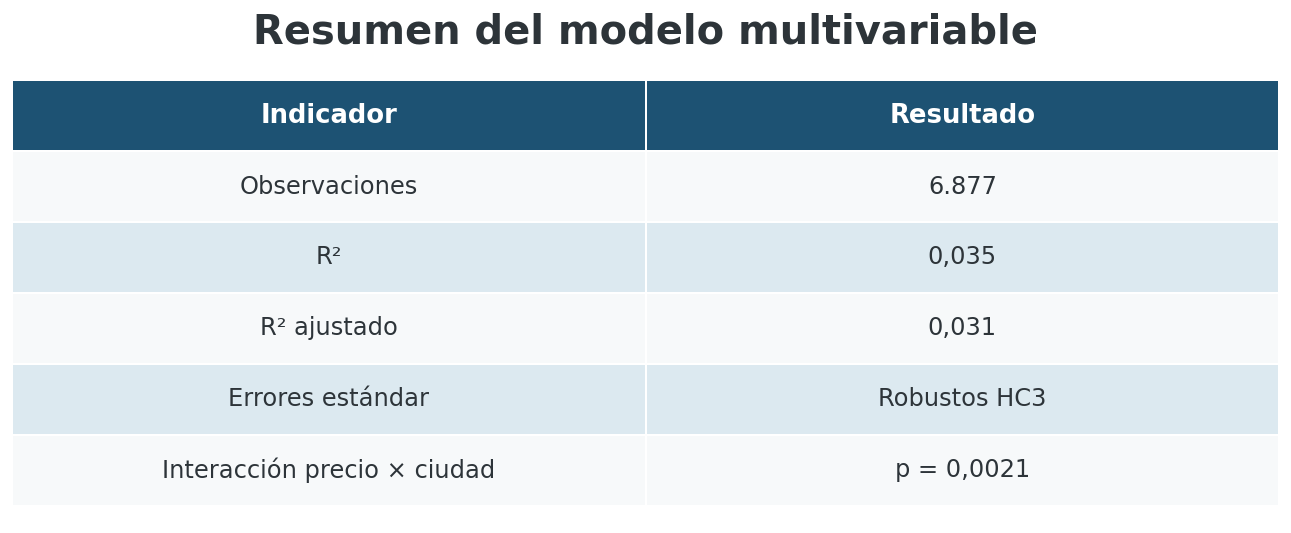

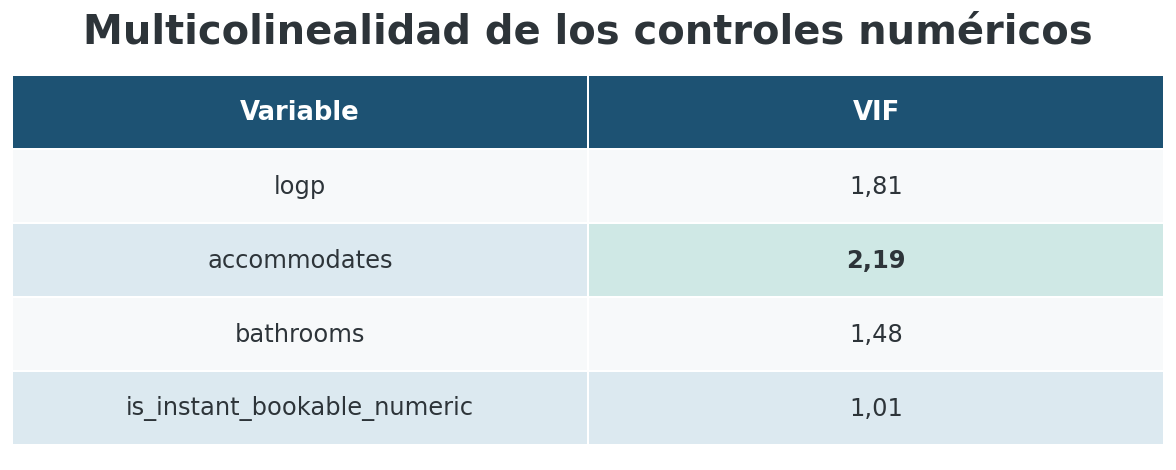

In [13]:
MODEL_COLUMNS = [
    "review_scores_rating",
    "logp",
    "city",
    "room_type",
    "accommodates",
    "bathrooms",
    "is_instant_bookable_numeric",
    "snapshot_year",
]

model_data = df_analysis[MODEL_COLUMNS].dropna().copy()

model_formula = (
    "review_scores_rating ~ logp * C(city)"
    " + C(room_type)"
    " + accommodates"
    " + bathrooms"
    " + is_instant_bookable_numeric"
    " + C(snapshot_year)"
)

adjusted_model = smf.ols(
    formula=model_formula,data=model_data,
).fit(cov_type="HC3")

# VIF de los controles numéricos principales.
vif_columns = [
    "logp",
    "accommodates",
    "bathrooms",
    "is_instant_bookable_numeric",
]

vif_data = add_constant(
    model_data[vif_columns].astype(float)
)

vif_table = pd.DataFrame(
    {
        "Variable": vif_data.columns,
        "VIF": [
            variance_inflation_factor(vif_data.values, index)
            for index in range(vif_data.shape[1])
        ],
    }
)

vif_table = (
    vif_table.loc[vif_table["Variable"] != "const"]
    .reset_index(drop=True)
)

# Prueba conjunta: ¿las pendientes precio–rating son iguales en todas las ciudades?
interaction_terms = [
    term
    for term in adjusted_model.params.index
    if term.startswith("logp:C(city)")
]

interaction_hypothesis = ", ".join(
    f"{term} = 0"
    for term in interaction_terms
)

interaction_test = adjusted_model.wald_test(
    interaction_hypothesis,
    scalar=True,
)

model_summary = pd.DataFrame(
    {
        "Indicador": [
            "Observaciones",
            "R²",
            "R² ajustado",
            "Errores estándar",
            "Interacción precio × ciudad",
        ],
        "Resultado": [
            format_es(adjusted_model.nobs, 0, thousands=True),
            format_es(adjusted_model.rsquared, 3),
            format_es(adjusted_model.rsquared_adj, 3),
            "Robustos HC3",
            f"p = {format_es(float(interaction_test.pvalue), 4)}",
        ],
    }
)

graphic_table(
    model_summary,
    "Resumen del modelo multivariable",
    width=11,font_size=14.5,
)

graphic_table(
    vif_table,
    "Multicolinealidad de los controles numéricos",
    formats={"VIF": "{:.2f}"},highlight_max=["VIF"],width=10,font_size=14.5,
)

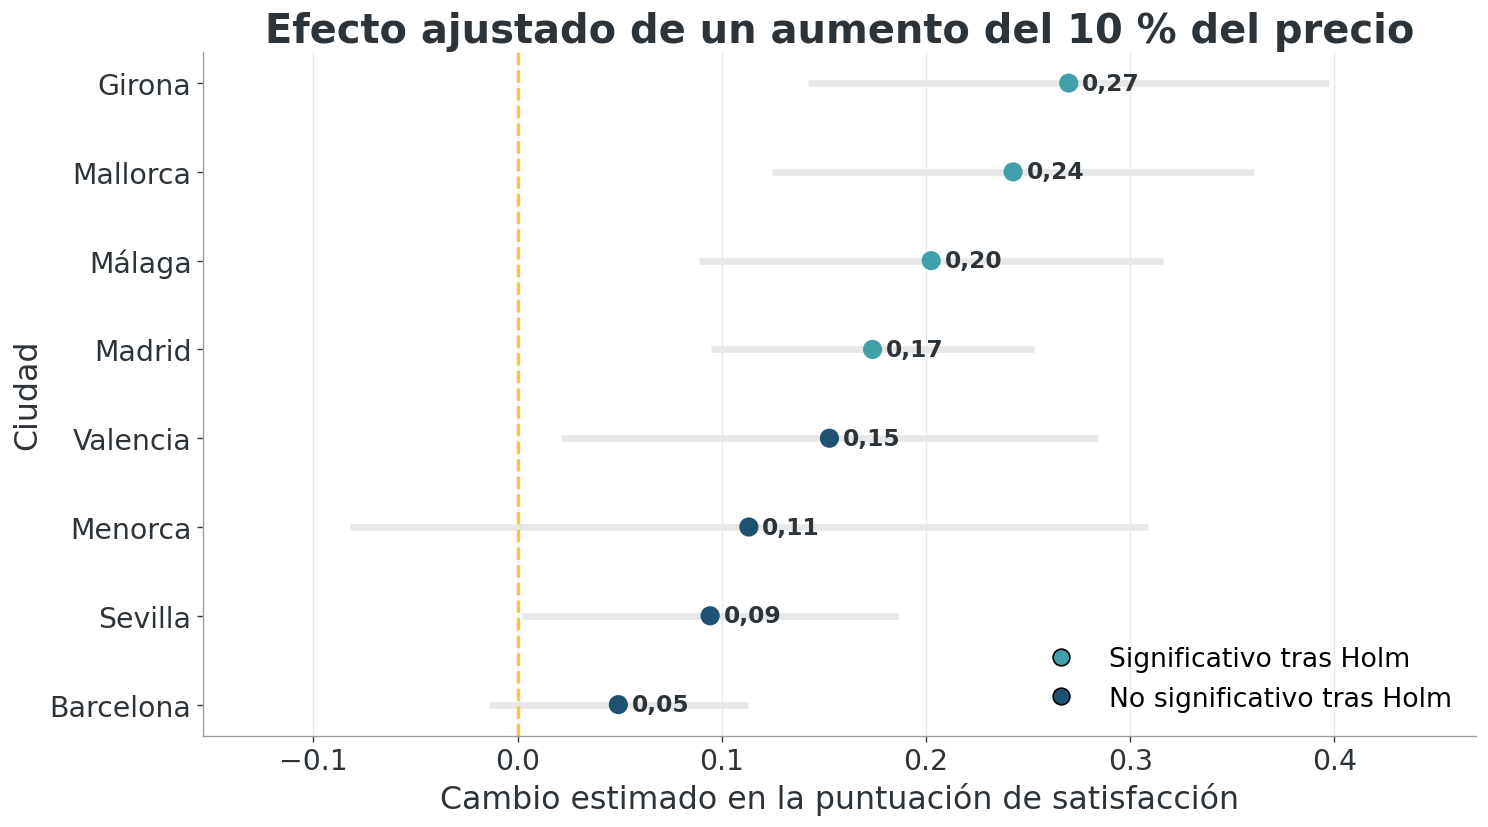

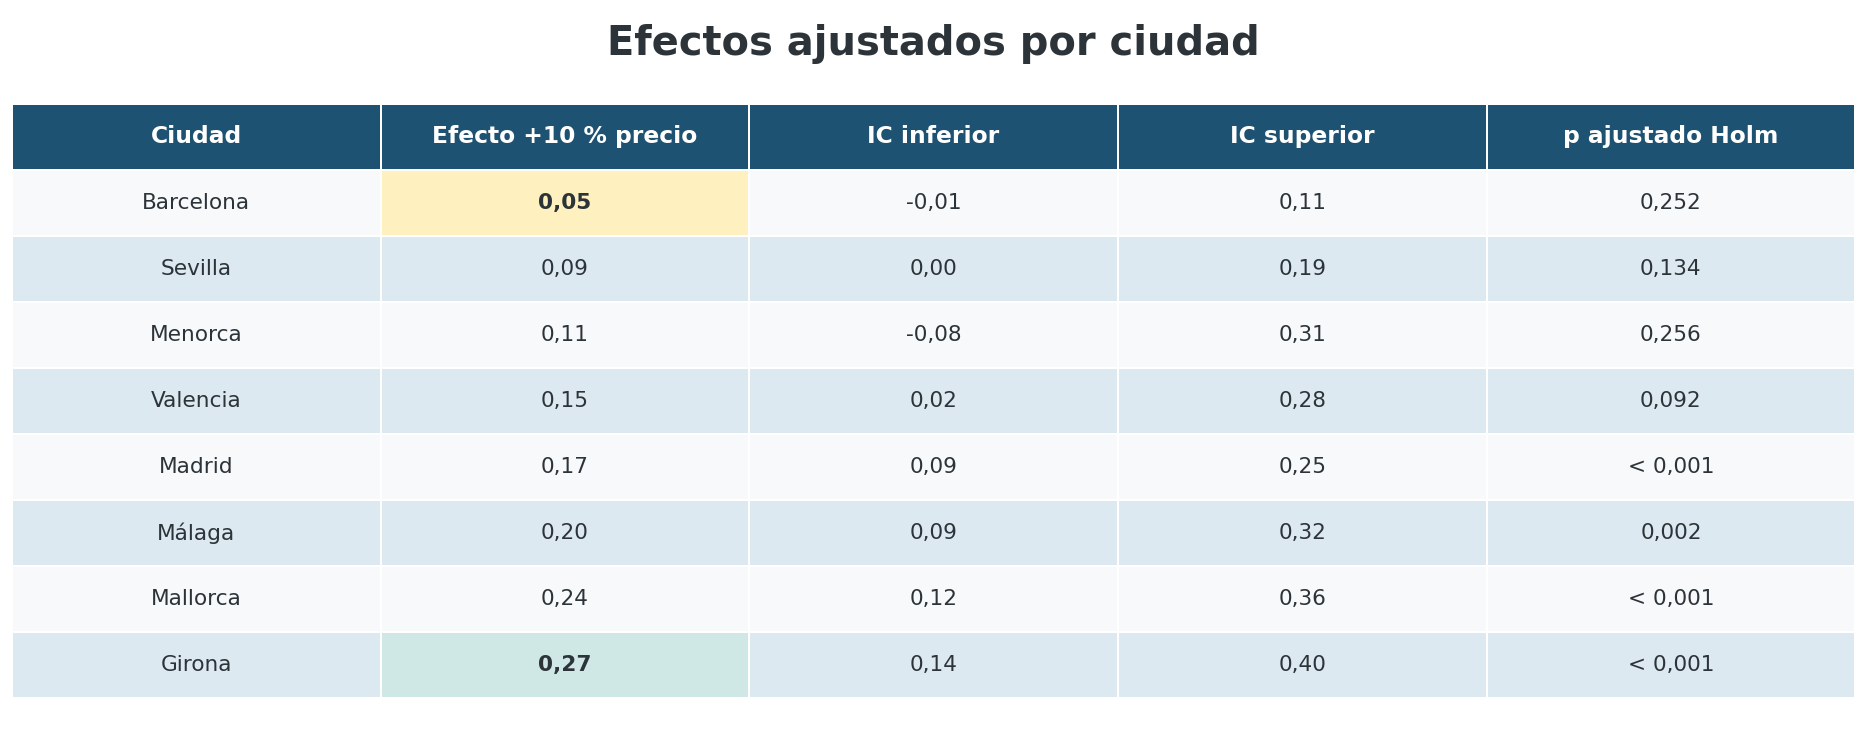

In [14]:
# Efecto ajustado asociado con un aumento del 10 % del precio.
baseline_city = sorted(model_data["city"].unique())[0]
covariance = adjusted_model.cov_params()
log_change_10 = np.log(1.10)

adjusted_rows = []

for city in sorted(model_data["city"].unique()):
    estimate = adjusted_model.params["logp"]
    variance = covariance.loc["logp", "logp"]

    if city != baseline_city:
        interaction = f"logp:C(city)[T.{city}]"
        estimate += adjusted_model.params[interaction]
        variance += (
            covariance.loc[interaction, interaction]
            + 2 * covariance.loc["logp", interaction]
        )

    standard_error = np.sqrt(variance)
    p_value = 2 * (1 - norm.cdf(abs(estimate / standard_error)))

    adjusted_rows.append(
        {
            "Ciudad": city,
            "Efecto +10 % precio": estimate * log_change_10,
            "IC inferior": (estimate - 1.96 * standard_error) * log_change_10,
            "IC superior": (estimate + 1.96 * standard_error) * log_change_10,
            "Valor p": p_value,
        }
    )

adjusted_effects = pd.DataFrame(adjusted_rows)
adjusted_effects["p ajustado Holm"] = holm_adjust(
    adjusted_effects["Valor p"].to_numpy()
)
adjusted_effects["Significativo Holm"] = (
    adjusted_effects["p ajustado Holm"] < 0.05
)
adjusted_effects = adjusted_effects.sort_values(
    "Efecto +10 % precio"
)

fig, ax = plt.subplots(figsize=(12.5, 7))

point_colors = np.where(
    adjusted_effects["Significativo Holm"],
    TEAL,
    NAVY,
)

ax.hlines(
    y=adjusted_effects["Ciudad"],xmin=adjusted_effects["IC inferior"],xmax=adjusted_effects["IC superior"],
    color=LIGHT_GREY,linewidth=4,
)
ax.scatter(
    adjusted_effects["Efecto +10 % precio"],
    adjusted_effects["Ciudad"],
    s=110,color=point_colors,zorder=3,
)

# Añadir el valor estimado junto a cada punto.
for _, row in adjusted_effects.iterrows():
    ax.annotate(
        format_es(row["Efecto +10 % precio"], 2),
        (
            row["Efecto +10 % precio"],
            row["Ciudad"],
        ),
        xytext=(8, 0),textcoords="offset points",va="center",fontsize=14,fontweight="bold",color=DARK,
    )

# Dejar espacio horizontal para que las etiquetas no se corten.
ax.margins(x=0.15)

ax.axvline(0, color=YELLOW, linestyle="--", linewidth=2)
ax.set(
    title="Efecto ajustado de un aumento del 10 % del precio",xlabel="Cambio estimado en la puntuación de satisfacción",ylabel="Ciudad",
)
ax.grid(axis="x")

legend_handles = [
    Line2D(
        [0], [0], marker="o", color="none",markerfacecolor=TEAL, markersize=10,label="Significativo tras Holm",
    ),
    Line2D(
        [0], [0], marker="o", color="none",markerfacecolor=NAVY, markersize=10,label="No significativo tras Holm",
    ),
]
ax.legend(handles=legend_handles, frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

adjusted_table = adjusted_effects[
    [
        "Ciudad",
        "Efecto +10 % precio",
        "IC inferior",
        "IC superior",
        "p ajustado Holm",
    ]
].copy()

adjusted_table["p ajustado Holm"] = adjusted_table[
    "p ajustado Holm"
].map(p_value_label)

graphic_table(
    adjusted_table,
    "Efectos ajustados por ciudad",
    formats={
        "Efecto +10 % precio": "{:.2f}",
        "IC inferior": "{:.2f}",
        "IC superior": "{:.2f}",
    },
    highlight_max=["Efecto +10 % precio"],highlight_min=["Efecto +10 % precio"],width=16,font_size=13,
)

### Interpretación del modelo

La interacción entre precio y ciudad es significativa (**p = 0,0021**), por lo que la relación ajustada no es igual en todas las ciudades.

Un aumento del **10 % del precio** se asocia con cambios estimados de aproximadamente **+0,05 puntos en Barcelona** a **+0,27 puntos en Girona**.

Algunas asociaciones siguen siendo significativas tras la corrección de Holm, pero su magnitud práctica es pequeña. Con una capacidad explicativa baja (**R² ≈ 0,035**), el precio y los controles disponibles explican solo una parte reducida de la satisfacción.

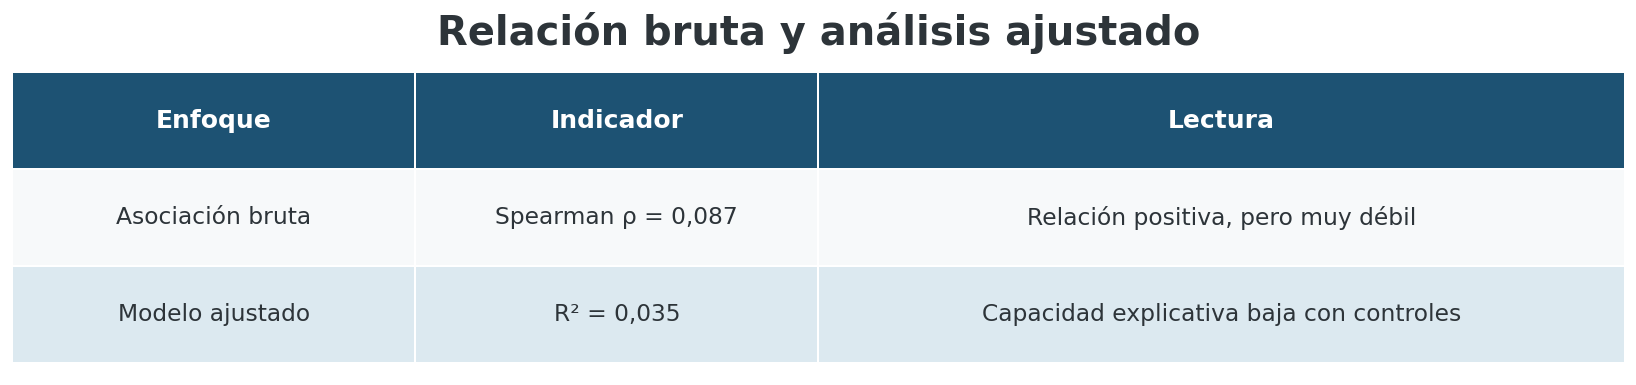

In [15]:
comparison_summary = pd.DataFrame(
    {
        "Enfoque": [
            "Asociación bruta",
            "Modelo ajustado",
        ],
        "Indicador": [
            f"Spearman ρ = {format_es(rho_global, 3)}",
            f"R² = {format_es(adjusted_model.rsquared, 3)}",
        ],
        "Lectura": [
            "Relación positiva, pero muy débil",
            "Capacidad explicativa baja con controles",
        ],
    }
)

graphic_table(
    comparison_summary,
    "Relación bruta y análisis ajustado",width=14,font_size=14,column_widths=[0.25, 0.25, 0.50],
)

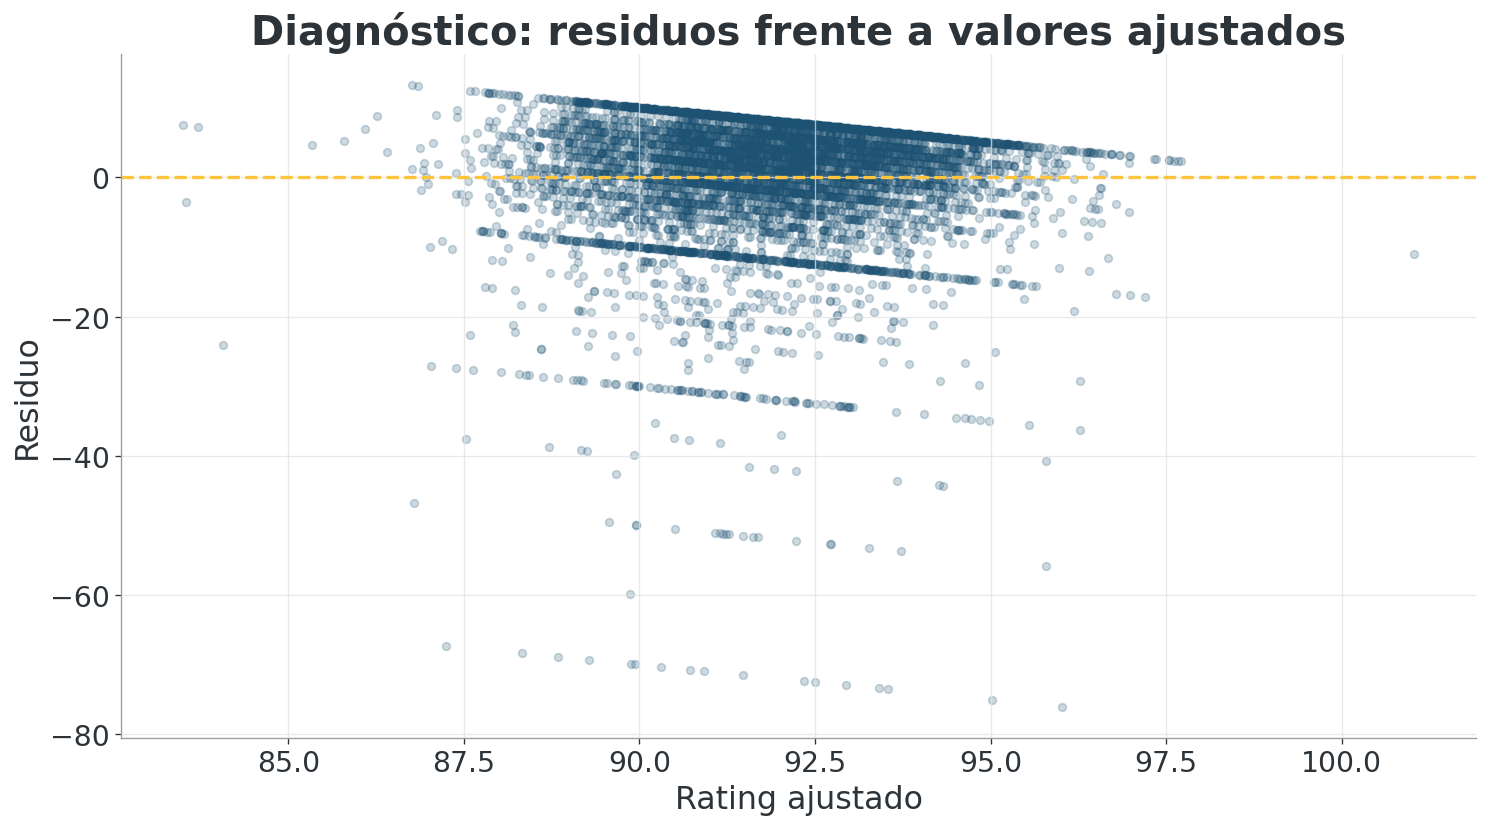

In [16]:
# Diagnóstico visual compacto del modelo.
fitted_values = adjusted_model.fittedvalues
residuals = adjusted_model.resid

fig, ax = plt.subplots(figsize=(12.5, 7))
ax.scatter(
    fitted_values,
    residuals,
    alpha=0.22,s=22,color=NAVY,
)
ax.axhline(0, color=YELLOW, linestyle="--", linewidth=2)
ax.set(
    title="Diagnóstico: residuos frente a valores ajustados",xlabel="Rating ajustado",ylabel="Residuo",
)
ax.grid()
plt.tight_layout()
plt.show()

### Supuestos y alcance del modelo

La satisfacción está limitada entre 0 y 100 y se concentra en puntuaciones altas. La regresión lineal se utiliza por su interpretabilidad, con errores estándar robustos HC3, y sus resultados se consideran aproximaciones asociativas.

La revisión VIF, calculada con constante, no detecta multicolinealidad severa entre los controles numéricos. No se incorporan simultáneamente `beds`, `bedrooms` y `accommodates`, porque representan dimensiones estructurales cercanas y dificultarían la interpretación.

El gráfico de residuos se utiliza como diagnóstico visual. El modelo:

- no se interpreta como causal;
- no se utiliza como herramienta predictiva;
- controla solo las variables observadas incluidas;
- puede mantener confusión residual por factores no disponibles en el dataset;
- comunica el bajo R² como un resultado relevante del negocio, no como un error del análisis.

El gráfico de residuos muestra un efecto techo claro, relacionado con la concentración de las puntuaciones en valores altos, y una dispersión que no es completamente constante. Los errores estándar robustos HC3 reducen el impacto de la heterocedasticidad sobre la inferencia, pero no corrigen las limitaciones de la forma funcional. Por este motivo, los coeficientes se interpretan como aproximaciones asociativas.

### 7.1 Comprobación de robustez: control por volumen de reseñas

Como prueba de robustez, se vuelve a estimar el modelo incorporando `log(number_of_reviews + 1)` como control adicional.

El número de reseñas puede aproximar la antigüedad, la popularidad y la estabilidad de la puntuación del alojamiento. Sin embargo, también podría formar parte del propio proceso que relaciona la experiencia con la satisfacción. Por este motivo se incorpora únicamente en un modelo secundario de robustez y no sustituye al modelo principal.

Para que la comparación sea válida, ambos modelos se estiman sobre exactamente la misma muestra.

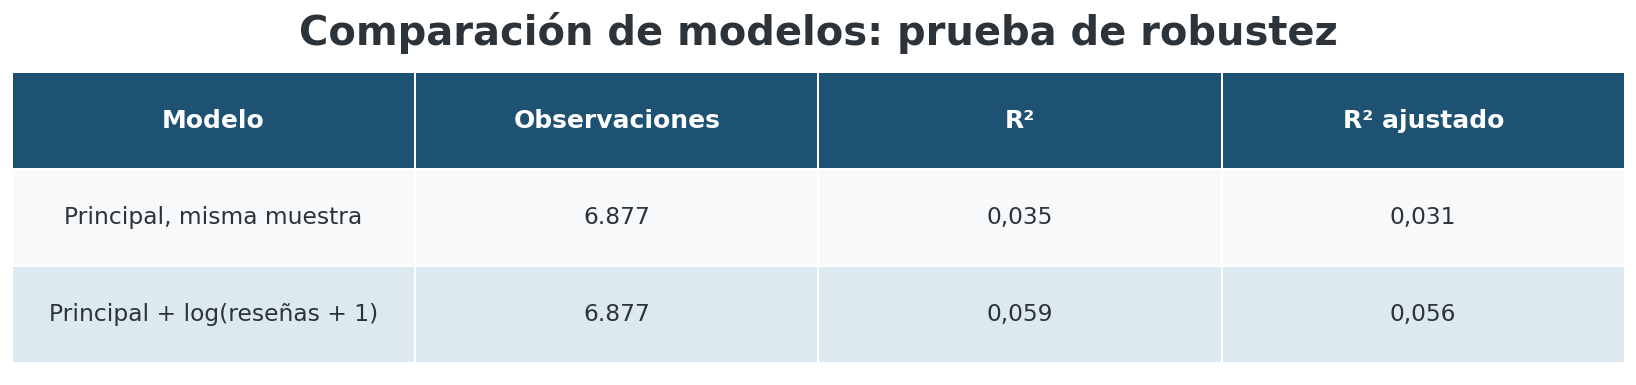

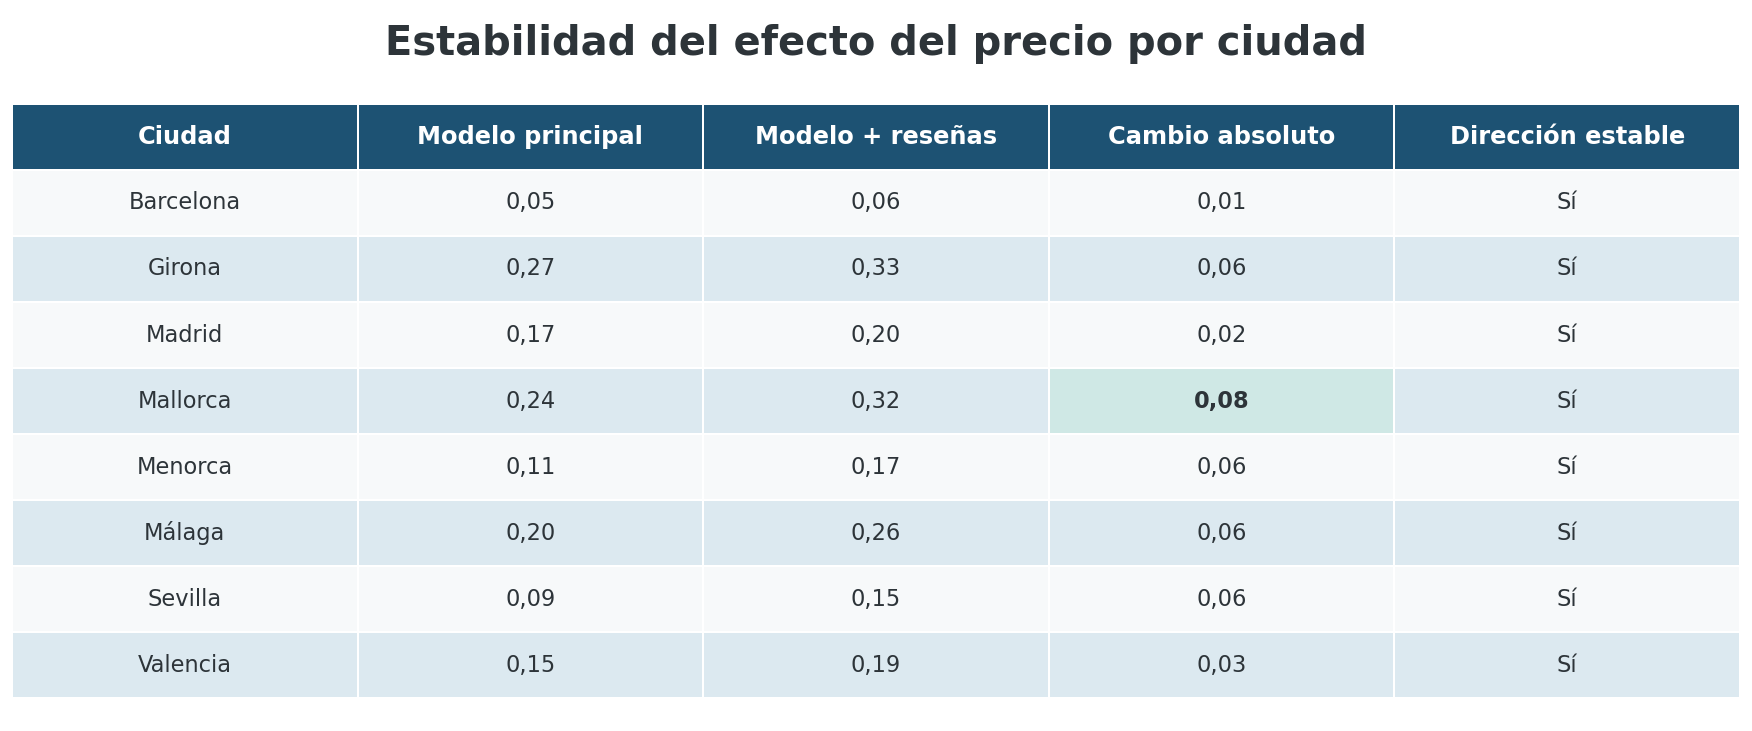

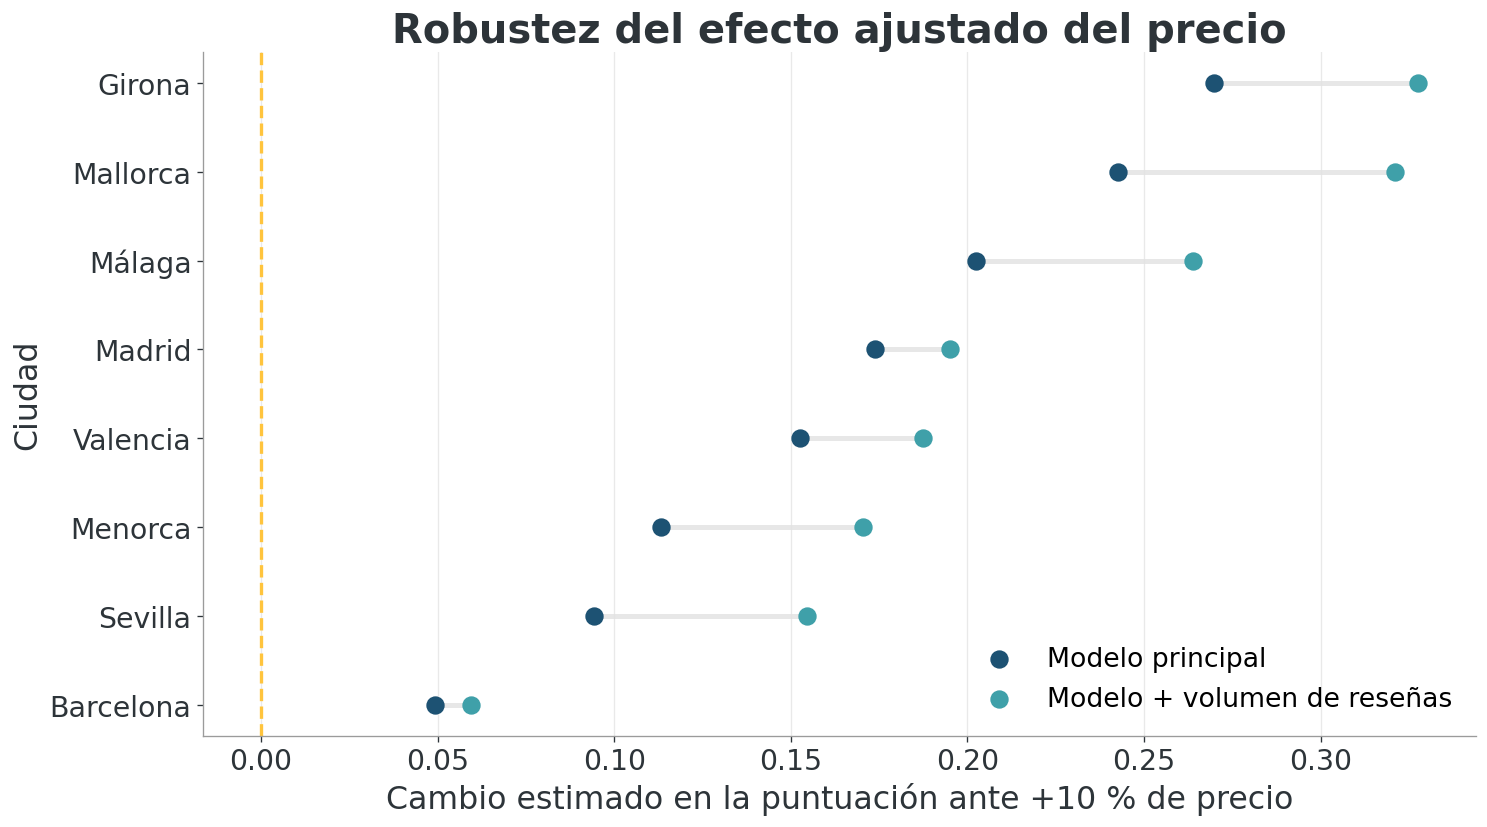

Coeficiente de log_reviews: 1.124
Valor p de log_reviews: < 0,001
Cambio máximo en el efecto del precio: 0.078
Ciudades con dirección estable: 8 de 8


In [17]:
robustness_columns = MODEL_COLUMNS + ["number_of_reviews"]

robustness_data = (
    df_analysis[robustness_columns]
    .dropna()
    .copy()
)

robustness_data["log_reviews"] = np.log1p(
    robustness_data["number_of_reviews"]
)


# Modelo principal reestimado sobre la misma muestra
main_comparable_model = smf.ols(
    formula=model_formula,data=robustness_data,
).fit(cov_type="HC3")


# Modelo de robustez con volumen de reseñas
robustness_formula = (
    model_formula
    + " + log_reviews"
)

robustness_model = smf.ols(
    formula=robustness_formula,data=robustness_data,
).fit(cov_type="HC3")


def extract_price_effects(model, data, column_name):
    """
    Calcula por ciudad el efecto ajustado asociado
    con un aumento del 10 % del precio.
    """

    baseline_city = sorted(data["city"].unique())[0]
    log_change_10 = np.log(1.10)
    rows = []

    for city in sorted(data["city"].unique()):
        estimate = model.params["logp"]

        if city != baseline_city:
            interaction_term = f"logp:C(city)[T.{city}]"

            if interaction_term not in model.params.index:
                interaction_term = f"C(city)[T.{city}]:logp"

            estimate += model.params[interaction_term]

        rows.append(
            {
                "Ciudad": city,
                column_name: estimate * log_change_10,
            }
        )

    return pd.DataFrame(rows)


# Efectos por ciudad en los dos modelos
main_robustness_effects = extract_price_effects(
    main_comparable_model,robustness_data,
    "Modelo principal",
)

review_control_effects = extract_price_effects(
    robustness_model,robustness_data,
    "Modelo + reseñas",
)


robustness_comparison = (
    main_robustness_effects
    .merge(
        review_control_effects,
        on="Ciudad",how="inner",
    )
)

robustness_comparison["Cambio absoluto"] = (
    robustness_comparison["Modelo + reseñas"]
    - robustness_comparison["Modelo principal"]
).abs()

robustness_comparison["Dirección estable"] = np.where(
    np.sign(robustness_comparison["Modelo principal"])
    == np.sign(robustness_comparison["Modelo + reseñas"]),
    "Sí",
    "No",
)


# Comparación general de los modelos
robustness_model_summary = pd.DataFrame(
    {
        "Modelo": [
            "Principal, misma muestra",
            "Principal + log(reseñas + 1)",
        ],
        "Observaciones": [
            main_comparable_model.nobs,
            robustness_model.nobs,
        ],
        "R²": [
            main_comparable_model.rsquared,
            robustness_model.rsquared,
        ],
        "R² ajustado": [
            main_comparable_model.rsquared_adj,
            robustness_model.rsquared_adj,
        ],
    }
)


graphic_table(
    robustness_model_summary,
    "Comparación de modelos: prueba de robustez",
    formats={
        "Observaciones": "{:,.0f}",
        "R²": "{:.3f}",
        "R² ajustado": "{:.3f}",
    },
    width=14,font_size=14,
)


graphic_table(
    robustness_comparison,
    "Estabilidad del efecto del precio por ciudad",
    formats={
        "Modelo principal": "{:.2f}",
        "Modelo + reseñas": "{:.2f}",
        "Cambio absoluto": "{:.2f}",
    },
    highlight_max=["Cambio absoluto"],width=15,font_size=13.5,
)


# Visualización comparativa
plot_data = robustness_comparison.sort_values(
    "Modelo principal"
).reset_index(drop=True)

y_positions = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(12.5, 7))

for index, row in plot_data.iterrows():
    ax.plot(
        [
            row["Modelo principal"],
            row["Modelo + reseñas"],
        ],
        [index, index],
        color=LIGHT_GREY,linewidth=3,zorder=1,
    )

ax.scatter(
    plot_data["Modelo principal"],y_positions,color=NAVY,s=100,label="Modelo principal",zorder=3,
)

ax.scatter(
    plot_data["Modelo + reseñas"],y_positions,color=TEAL,s=100,label="Modelo + volumen de reseñas",zorder=3,
)

ax.axvline(
    0,color=YELLOW,linestyle="--",linewidth=2,
)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_data["Ciudad"])

ax.set(
    title="Robustez del efecto ajustado del precio",xlabel="Cambio estimado en la puntuación ante +10 % de precio",ylabel="Ciudad",
)

ax.legend(
    frameon=False,loc="lower right",
)

ax.grid(axis="x")

plt.tight_layout()
plt.show()


print(
    "Coeficiente de log_reviews:",
    f"{robustness_model.params['log_reviews']:.3f}",
)

print(
    "Valor p de log_reviews:",
    p_value_label(
        robustness_model.pvalues["log_reviews"]
    ),
)

print(
    "Cambio máximo en el efecto del precio:",
    f"{robustness_comparison['Cambio absoluto'].max():.3f}",
)

print(
    "Ciudades con dirección estable:",
    (
        robustness_comparison["Dirección estable"]
        .eq("Sí")
        .sum()
    ),
    "de",
    len(robustness_comparison),
)

### Interpretación de la prueba de robustez

Ambos modelos se estiman sobre la misma muestra de **6.877 alojamientos**. Al incorporar el volumen de reseñas, la capacidad explicativa aumenta de **R² = 0,035** a **R² = 0,059**, aunque sigue siendo limitada.

El efecto ajustado del precio mantiene la misma dirección en las ocho ciudades y la diferencia máxima entre ambos modelos es de solo **0,078 puntos de rating** ante un aumento del 10 % del precio. Por tanto, la conclusión principal se mantiene estable.

`log_reviews` presenta una asociación positiva y significativa con el rating (**β = 1,124; p < 0,001**), pero este resultado no debe interpretarse como causal.

## 8. Traducción del resultado a impacto de negocio

La correlación puede ser difícil de interpretar para una decisión comercial. Por ello, dentro de cada ciudad se comparan:

- **Q1:** el cuartil inferior de precio, formado aproximadamente por el 25 % de los alojamientos más económicos.

- **Q4:** el cuartil superior de precio, formado aproximadamente por el 25 % de los alojamientos más caros.

Las medianas se presentan como resumen descriptivo. La prueba de Mann–Whitney U evalúa si la distribución y los rangos de satisfacción difieren entre Q1 y Q4, mientras que el delta de Cliff cuantifica la magnitud práctica de esa diferencia.

### Hipótesis

- **H₀:** la distribución de satisfacción es similar en Q1 y Q4.
- **H₁:** la distribución de satisfacción es diferente entre Q1 y Q4.

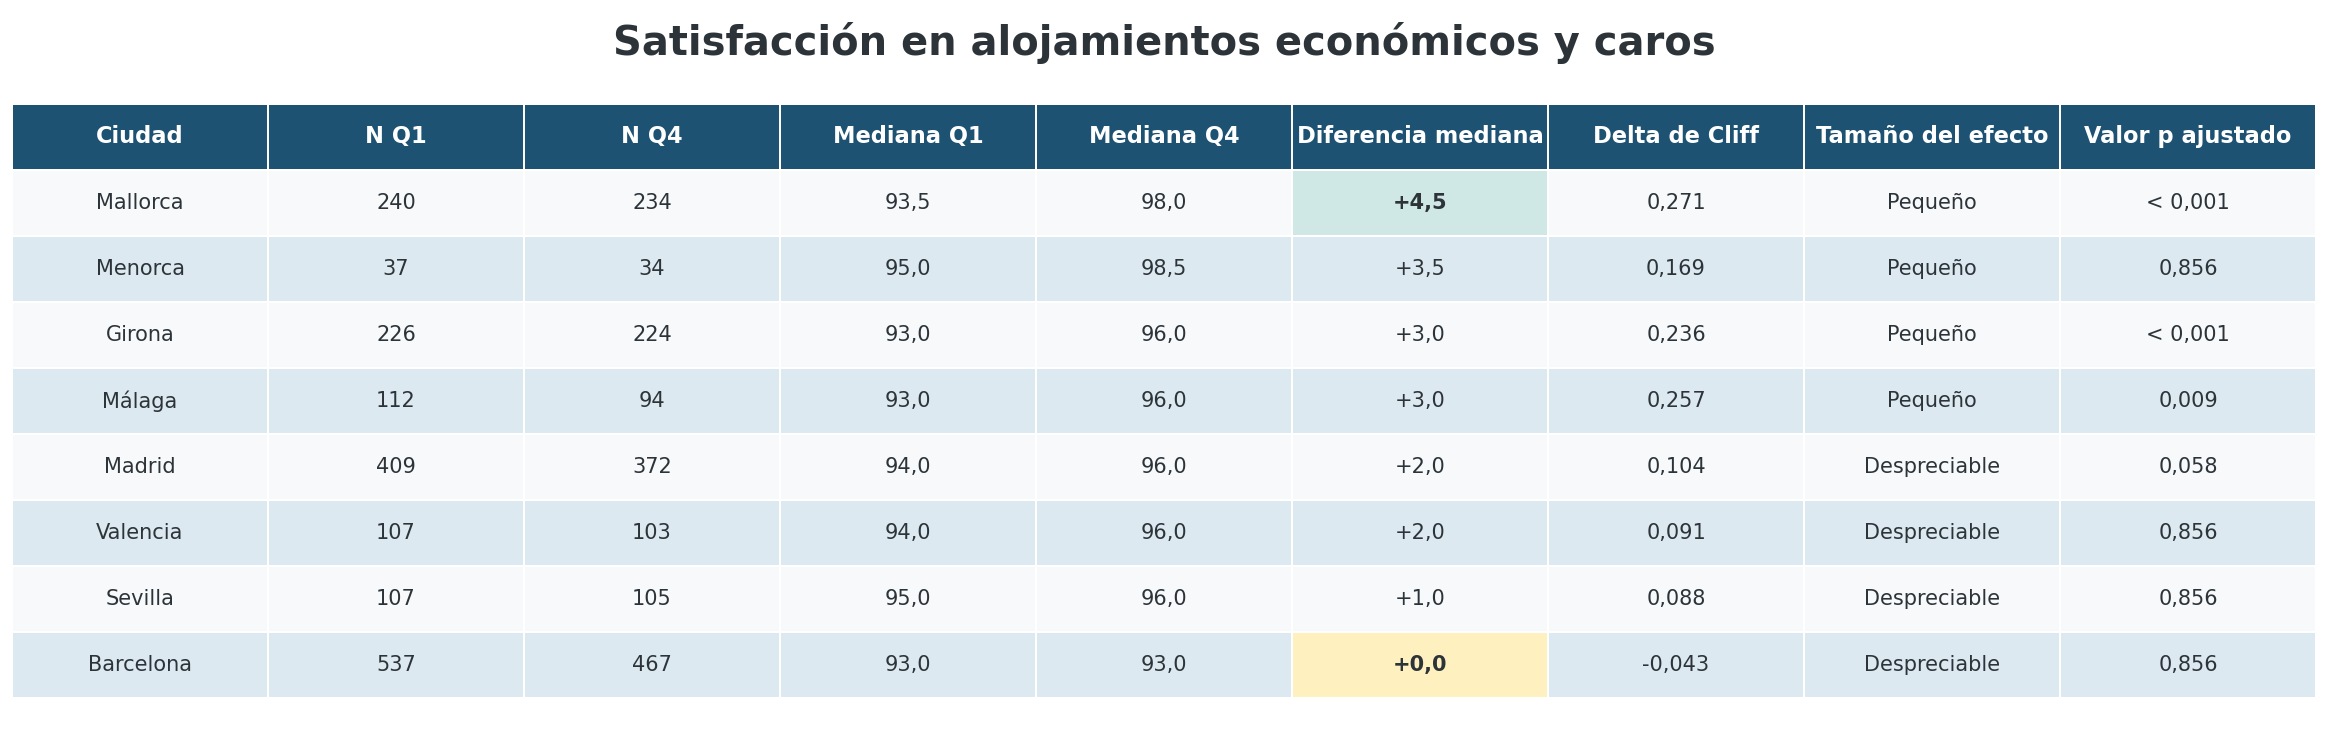

In [18]:
df_analysis["Cuartil de precio"] = df_analysis.groupby("city")[
    "price_€"
].transform(
    lambda series: quantile_groups(
        series,
        4,
        labels=["Q1", "Q2", "Q3", "Q4"],
    )
)

quartile_rows = []

for city, city_data in df_analysis.groupby("city"):
    low = city_data.loc[
        city_data["Cuartil de precio"] == "Q1",
        "review_scores_rating",
    ]
    high = city_data.loc[
        city_data["Cuartil de precio"] == "Q4",
        "review_scores_rating",
    ]
    _, p_value, cliff_delta = mann_whitney_effect(high, low)

    quartile_rows.append(
        {
            "Ciudad": city,
            "N Q1": len(low),
            "N Q4": len(high),
            "Mediana Q1": low.median(),
            "Mediana Q4": high.median(),
            "Diferencia mediana": high.median() - low.median(),
            "Valor p": p_value,
            "Delta de Cliff": cliff_delta,
            "Tamaño del efecto": effect_label(cliff_delta),
        }
    )

quartile_results = pd.DataFrame(quartile_rows)
quartile_results["Valor p ajustado"] = holm_adjust(
    quartile_results["Valor p"]
)
quartile_results = quartile_results.sort_values(
    "Diferencia mediana",
    ascending=False,
).reset_index(drop=True)

quartile_table = quartile_results[
    [
        "Ciudad",
        "N Q1",
        "N Q4",
        "Mediana Q1",
        "Mediana Q4",
        "Diferencia mediana",
        "Delta de Cliff",
        "Tamaño del efecto",
        "Valor p ajustado",
    ]
].copy()
quartile_table["Valor p ajustado"] = quartile_table[
    "Valor p ajustado"
].map(p_value_label)

graphic_table(
    quartile_table,
    "Satisfacción en alojamientos económicos y caros",
    formats={
        "N Q1": "{:,.0f}",
        "N Q4": "{:,.0f}",
        "Mediana Q1": "{:.1f}",
        "Mediana Q4": "{:.1f}",
        "Diferencia mediana": "{:+.1f}",
        "Delta de Cliff": "{:.3f}",
    },
    highlight_max=["Diferencia mediana"],highlight_min=["Diferencia mediana"],width=20,font_size=12.5,
)

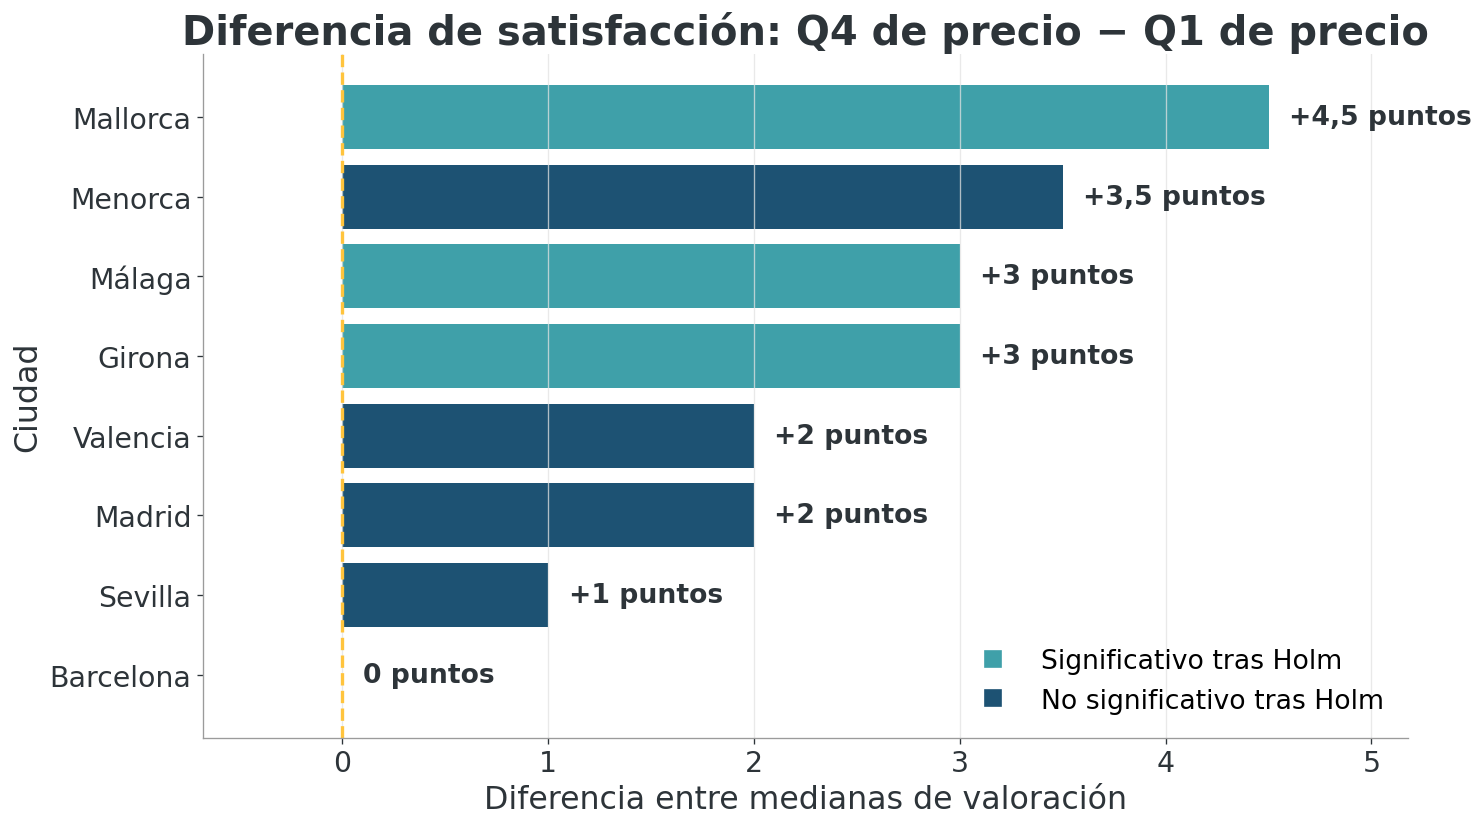

In [19]:
quartile_plot = quartile_results.sort_values(
    "Diferencia mediana",
    ascending=True,
).copy()

colors = [
    TEAL if p_value < 0.05 else GREY if difference == 0 else NAVY
    for p_value, difference in zip(
        quartile_plot["Valor p ajustado"],
        quartile_plot["Diferencia mediana"],
    )
]

fig, ax = plt.subplots(figsize=(12.5, 7))
bars = ax.barh(
    quartile_plot["Ciudad"],
    quartile_plot["Diferencia mediana"],
    color=colors,
)

label_offset = 0.10

for bar, value in zip(
    bars,
    quartile_plot["Diferencia mediana"],
):
    decimals = (
        0
        if np.isclose(value, round(value))
        else 1
    )

    label = format_es(value, decimals)
    sign = "+" if value > 0 else ""
    y_center = bar.get_y() + bar.get_height() / 2

    ax.text(
        (
            value + label_offset
            if value >= 0
            else value - label_offset
        ),
        y_center,
        f"{sign}{label} puntos",
        va="center",ha="left" if value >= 0 else "right",fontsize=DATA_LABEL_SIZE,color=DARK,fontweight="bold",
    )

minimum_difference = quartile_plot[
    "Diferencia mediana"
].min()

maximum_difference = quartile_plot[
    "Diferencia mediana"
].max()

axis_margin = max(
    0.5,
    (
        maximum_difference
        - minimum_difference
    )
    * 0.15,
)

ax.axvline(
    0,color=YELLOW,linestyle="--",linewidth=2,
)

ax.set(
    title="Diferencia de satisfacción: Q4 de precio − Q1 de precio", xlabel="Diferencia entre medianas de valoración",ylabel="Ciudad",
)

ax.set_xlim(
    min(-0.5, minimum_difference - axis_margin),
    maximum_difference + axis_margin,
)
ax.grid(axis="x")

legend_handles = [
    Line2D(
        [0],[0],marker="s",color=TEAL,linestyle="none",markersize=10,label="Significativo tras Holm",
    ),
    Line2D(
        [0],[0],marker="s",color=NAVY,linestyle="none",markersize=10,label="No significativo tras Holm",
    ),
]
ax.legend(handles=legend_handles, frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

### Interpretación

La comparación Q4–Q1 traduce la asociación a diferencias más fáciles de interpretar:

- **Mallorca: +4,5 puntos**
- **Málaga y Girona: +3 puntos**
- **Menorca: +3,5 puntos**, aunque sin significación tras Holm
- **Barcelona: 0 puntos**

Tras la corrección de Holm, Mallorca, Málaga y Girona muestran diferencias estadísticamente significativas. Sin embargo, los tamaños del efecto siguen siendo pequeños o despreciables, por lo que no conviene convertir estas diferencias en una regla automática de pricing.

## 9. Análisis de sensibilidad

Se comprueba si la conclusión cambia al exigir al menos cinco reseñas. El objetivo es reducir el peso de valoraciones basadas en muy pocas opiniones.

También se revisa si la relación global depende del 1 % de alojamientos con los precios más altos. Estos casos no se eliminan del análisis principal, ya que pueden corresponder a ofertas reales.

Finalmente, se revisa el año del snapshot. Los precios proceden de distintos periodos, por lo que el dataset no representa un único momento del mercado.

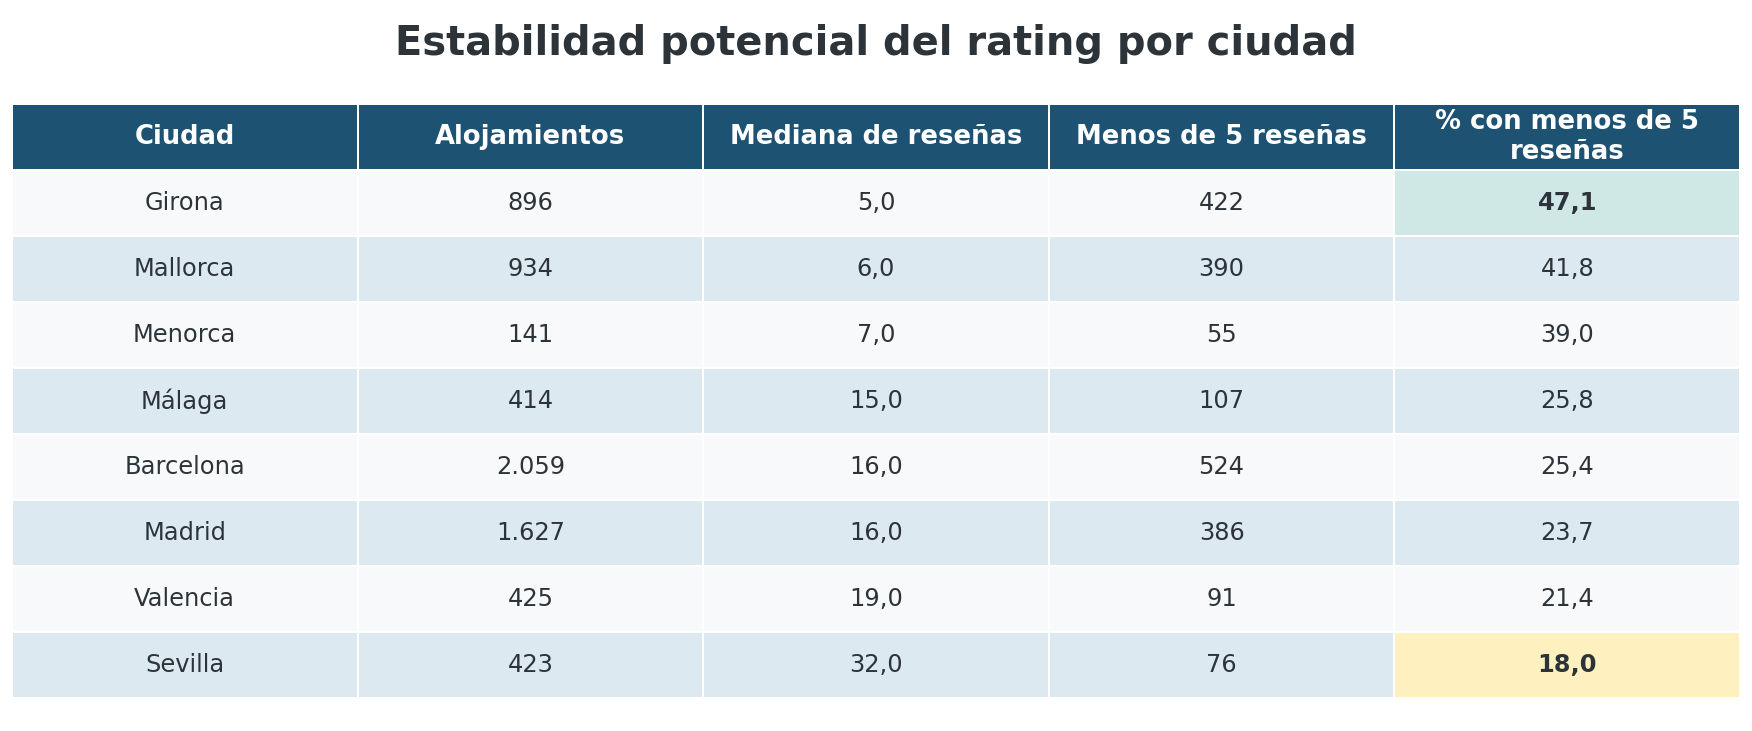

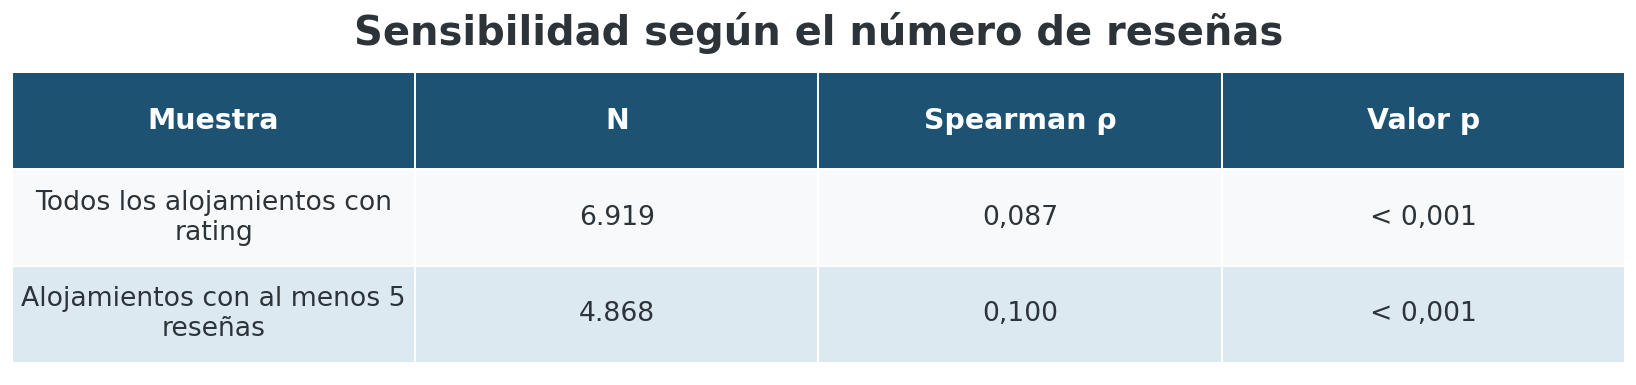

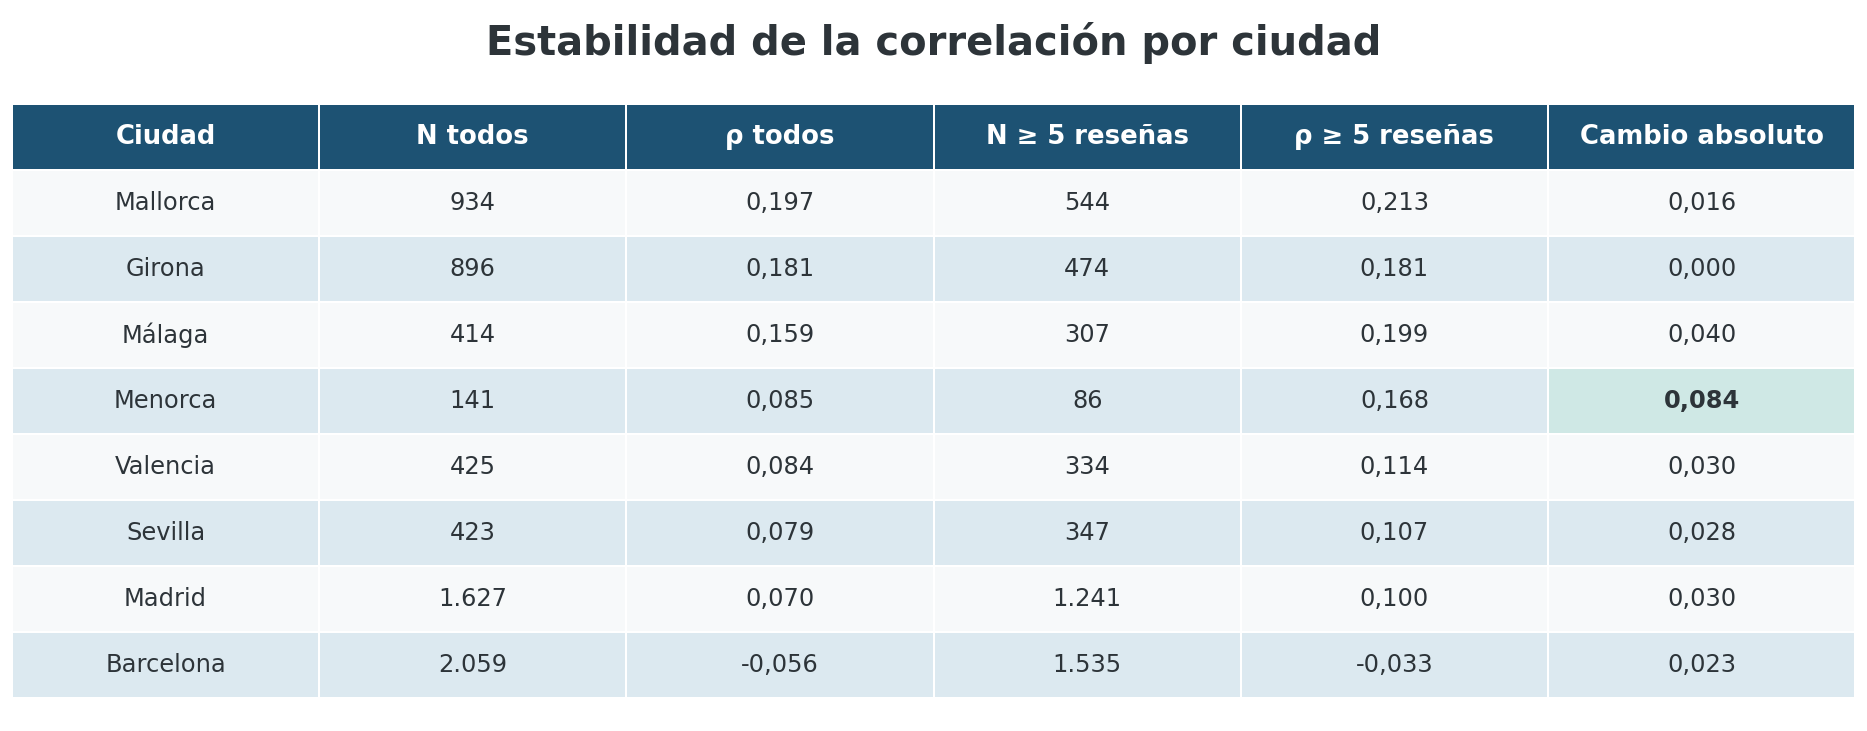

In [20]:
reviews_profile = (
    df_analysis.groupby("city")
    .agg(
        Alojamientos=("apartment_id", "size"),
        Mediana_reseñas=("number_of_reviews", "median"),
        Menos_de_5_reseñas=(
            "number_of_reviews",
            lambda values: (values < 5).sum(),
        ),
    )
    .reset_index()
    .rename(
        columns={
            "city": "Ciudad",
            "Mediana_reseñas": "Mediana de reseñas",
            "Menos_de_5_reseñas": "Menos de 5 reseñas",
        }
    )
)
reviews_profile["% con menos de 5 reseñas"] = (
    reviews_profile["Menos de 5 reseñas"]
    / reviews_profile["Alojamientos"]
    * 100
)
reviews_profile = reviews_profile.sort_values(
    "% con menos de 5 reseñas",
    ascending=False,
)

graphic_table(
    reviews_profile,
    "Estabilidad potencial del rating por ciudad",
    formats={
        "Alojamientos": "{:,.0f}",
        "Mediana de reseñas": "{:.1f}",
        "Menos de 5 reseñas": "{:,.0f}",
        "% con menos de 5 reseñas": "{:.1f}",
    },
    highlight_max=["% con menos de 5 reseñas"],highlight_min=["% con menos de 5 reseñas"],width=15,
)

sensitivity_data = df_analysis.loc[
    df_analysis["number_of_reviews"] >= 5
].copy()

rho_reviews, p_reviews = spearmanr(
    sensitivity_data["price_€"],
    sensitivity_data["review_scores_rating"],
)

base_rho_by_city = city_results.set_index("Ciudad")["Spearman ρ"]

sensitivity_rows = []
for city, city_data in df_analysis.groupby("city"):
    base_rho = base_rho_by_city.loc[city]

    stable_data = city_data.loc[city_data["number_of_reviews"] >= 5]
    stable_rho = spearmanr(
        stable_data["price_€"],
        stable_data["review_scores_rating"],
    ).statistic

    sensitivity_rows.append(
        {
            "Ciudad": city,
            "N todos": len(city_data),
            "ρ todos": base_rho,
            "N ≥ 5 reseñas": len(stable_data),
            "ρ ≥ 5 reseñas": stable_rho,
            "Cambio absoluto": abs(stable_rho - base_rho),
        }
    )

sensitivity_results = pd.DataFrame(sensitivity_rows).sort_values(
    "ρ todos",
    ascending=False,
)

global_sensitivity = pd.DataFrame(
    {
        "Muestra": [
            "Todos los alojamientos con rating",
            "Alojamientos con al menos 5 reseñas",
        ],
        "N": [len(df_analysis), len(sensitivity_data)],
        "Spearman ρ": [rho_global, rho_reviews],
        "Valor p": [p_global, p_reviews],
    }
)
global_sensitivity_table = global_sensitivity.copy()
global_sensitivity_table["Valor p"] = global_sensitivity_table[
    "Valor p"
].map(p_value_label)

graphic_table(
    global_sensitivity_table,
    "Sensibilidad según el número de reseñas",
    formats={
        "N": "{:,.0f}",
        "Spearman ρ": "{:.3f}",
    },
    width=14,
)

graphic_table(
    sensitivity_results,
    "Estabilidad de la correlación por ciudad",
    formats={
        "N todos": "{:,.0f}",
        "ρ todos": "{:.3f}",
        "N ≥ 5 reseñas": "{:,.0f}",
        "ρ ≥ 5 reseñas": "{:.3f}",
        "Cambio absoluto": "{:.3f}",
    },
    highlight_max=["Cambio absoluto"],width=16,
)

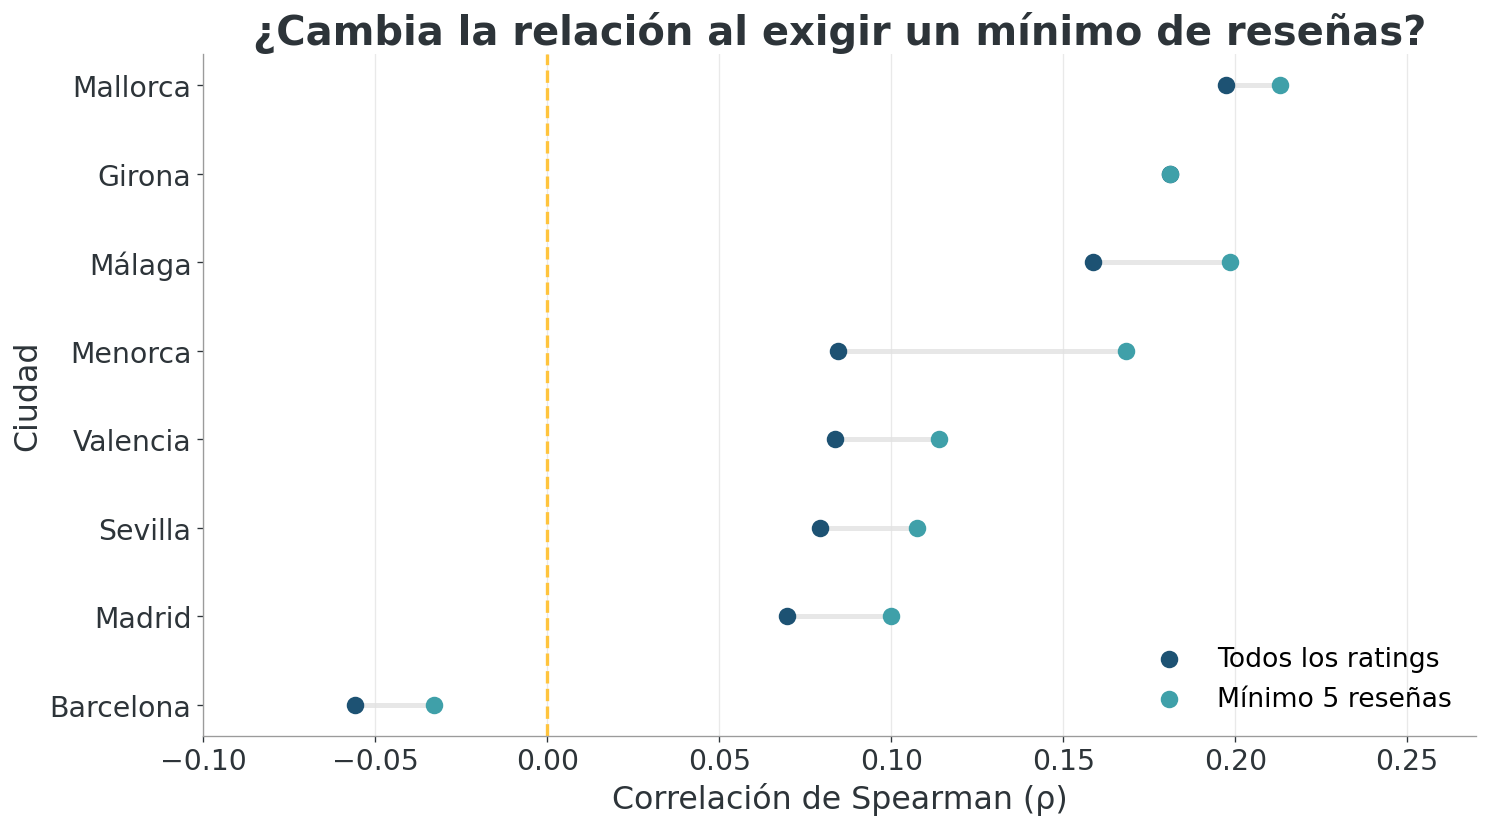

In [21]:
sensitivity_plot = sensitivity_results.sort_values("ρ todos").copy()
y_positions = np.arange(len(sensitivity_plot))

fig, ax = plt.subplots(figsize=(12.5, 7))

for y, (_, row) in zip(y_positions, sensitivity_plot.iterrows()):
    ax.plot(
        [row["ρ todos"], row["ρ ≥ 5 reseñas"]],
        [y, y],
        color=LIGHT_GREY,
        linewidth=3,
        zorder=1,
    )

ax.scatter(
    sensitivity_plot["ρ todos"],y_positions,s=90,color=NAVY,label="Todos los ratings",zorder=2,
)
ax.scatter(
    sensitivity_plot["ρ ≥ 5 reseñas"],y_positions,s=90,color=TEAL,label="Mínimo 5 reseñas",zorder=3,
)

ax.axvline(0, color=YELLOW, linestyle="--", linewidth=2)
ax.set_yticks(y_positions)
ax.set_yticklabels(sensitivity_plot["Ciudad"])
ax.set(
    title="¿Cambia la relación al exigir un mínimo de reseñas?",xlabel="Correlación de Spearman (ρ)",ylabel="Ciudad",xlim=(-0.10, 0.27),
)
ax.grid(axis="x")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

### Sensibilidad ante precios extremos

Los precios más altos no se eliminan del análisis principal porque pueden corresponder a alojamientos reales de gama alta. Como comprobación de sensibilidad, se repite la correlación excluyendo únicamente el 1 % superior de precios.

El objetivo es comprobar si la conclusión general está determinada por un número reducido de alojamientos especialmente caros.

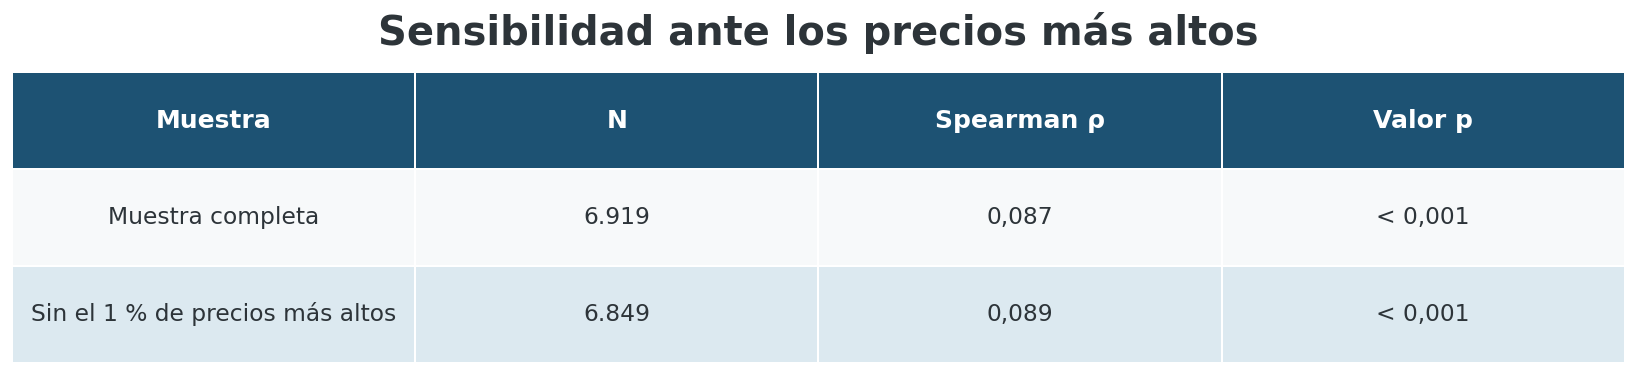

Cambio absoluto en Spearman ρ: 0,001
La conclusión se mantiene estable.


In [22]:
price_p99 = df_analysis["price_€"].quantile(0.99)

without_extreme_prices = df_analysis.loc[
    df_analysis["price_€"] <= price_p99
].copy()

rho_without_extremes, p_without_extremes = spearmanr(
    without_extreme_prices["price_€"],
    without_extreme_prices["review_scores_rating"],
)

extreme_price_sensitivity = pd.DataFrame(
    {
        "Muestra": [
            "Muestra completa",
            "Sin el 1 % de precios más altos",
        ],
        "N": [
            len(df_analysis),
            len(without_extreme_prices),
        ],
        "Spearman ρ": [
            rho_global,
            rho_without_extremes,
        ],
        "Valor p": [
            p_global,
            p_without_extremes,
        ],
    }
)

extreme_price_table = extreme_price_sensitivity.copy()

extreme_price_table["Valor p"] = (
    extreme_price_table["Valor p"]
    .map(p_value_label)
)

graphic_table(
    extreme_price_table,
    "Sensibilidad ante los precios más altos",
    formats={
        "N": "{:,.0f}",
        "Spearman ρ": "{:.3f}",
    },
    width=14,
    font_size=14,
)

rho_change_extremes = abs(
    rho_without_extremes - rho_global
)

stability_message = (
    "La conclusión se mantiene estable."
    if rho_change_extremes < 0.02
    else "La relación muestra una variación apreciable."
)

print(
    "Cambio absoluto en Spearman ρ:",
    format_es(rho_change_extremes, 3),
)

print(stability_message)

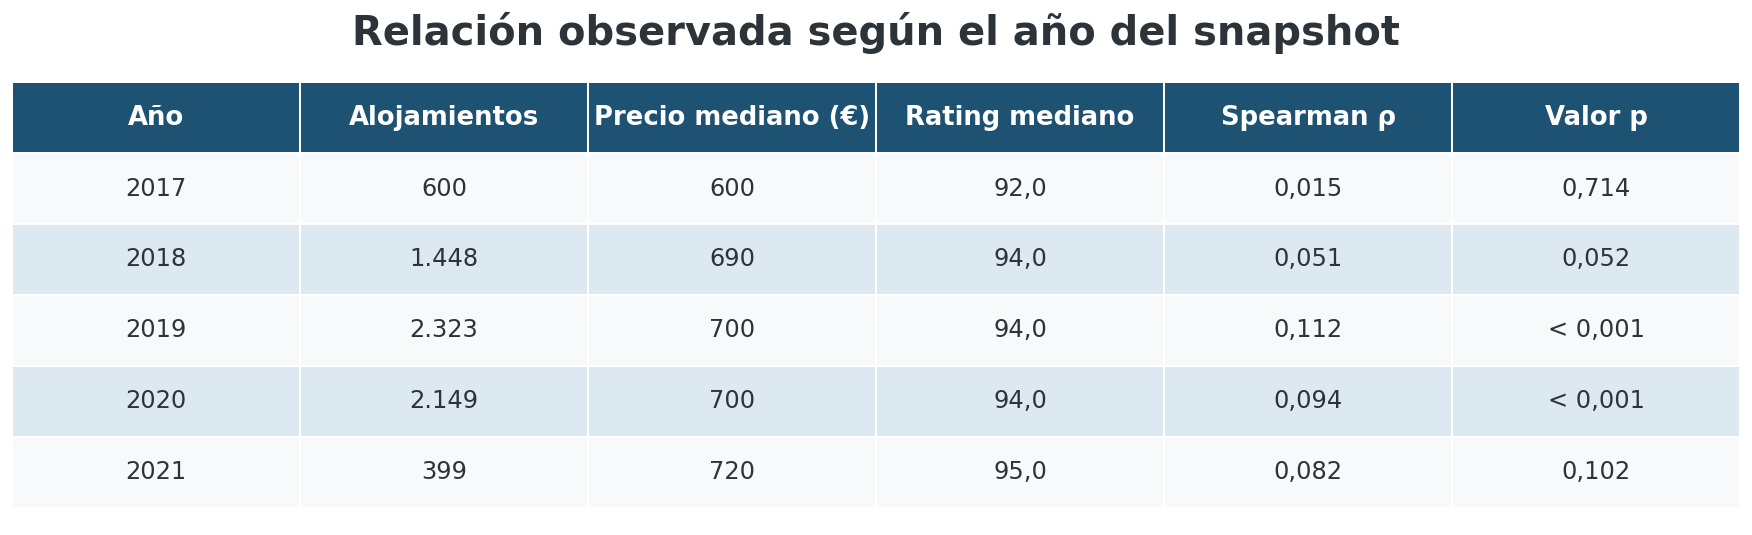

In [23]:
year_rows = []

for year, year_data in df_analysis.groupby("snapshot_year"):
    rho, p_value = spearmanr(
        year_data["price_€"],
        year_data["review_scores_rating"],
    )
    year_rows.append(
        {
            "Año": int(year),
            "Alojamientos": len(year_data),
            "Precio mediano (€)": year_data["price_€"].median(),
            "Rating mediano": year_data["review_scores_rating"].median(),
            "Spearman ρ": rho,
            "Valor p": p_value,
        }
    )

year_results = pd.DataFrame(year_rows)
year_table = year_results.copy()
year_table["Valor p"] = year_table["Valor p"].map(p_value_label)

graphic_table(
    year_table,
    "Relación observada según el año del snapshot",
    formats={
        "Año": "{:.0f}",
        "Alojamientos": "{:,.0f}",
        "Precio mediano (€)": "{:,.0f}",
        "Rating mediano": "{:.1f}",
        "Spearman ρ": "{:.3f}",
    },
    width=15,
)

### Interpretación

La conclusión es estable al exigir al menos cinco reseñas:

- muestra completa: **ρ = 0,087**
- mínimo cinco reseñas: **ρ = 0,100**

La relación continúa siendo muy débil. Girona (**47,1 %**), Mallorca (**41,8 %**) y Menorca (**39,0 %**) concentran más alojamientos con pocas reseñas, mientras que Sevilla presenta una mayor estabilidad potencial.

La comparación sin el 1 % de precios más altos muestra que la correlación cambia únicamente de **ρ = 0,087** a **ρ = 0,089**, con una diferencia absoluta de **0,001** según el cálculo no redondeado. Por tanto, la conclusión global no depende de un número reducido de alojamientos excepcionalmente caros.

El análisis por año es descriptivo: las diferencias pueden reflejar tanto cambios temporales como cambios en la composición de ciudades y alojamientos.

## 10. Sesgos, limitaciones y medidas aplicadas

No todos los riesgos pueden eliminarse con este dataset. La tabla distingue entre los sesgos que pueden comprobarse y las limitaciones que solo pueden documentarse.

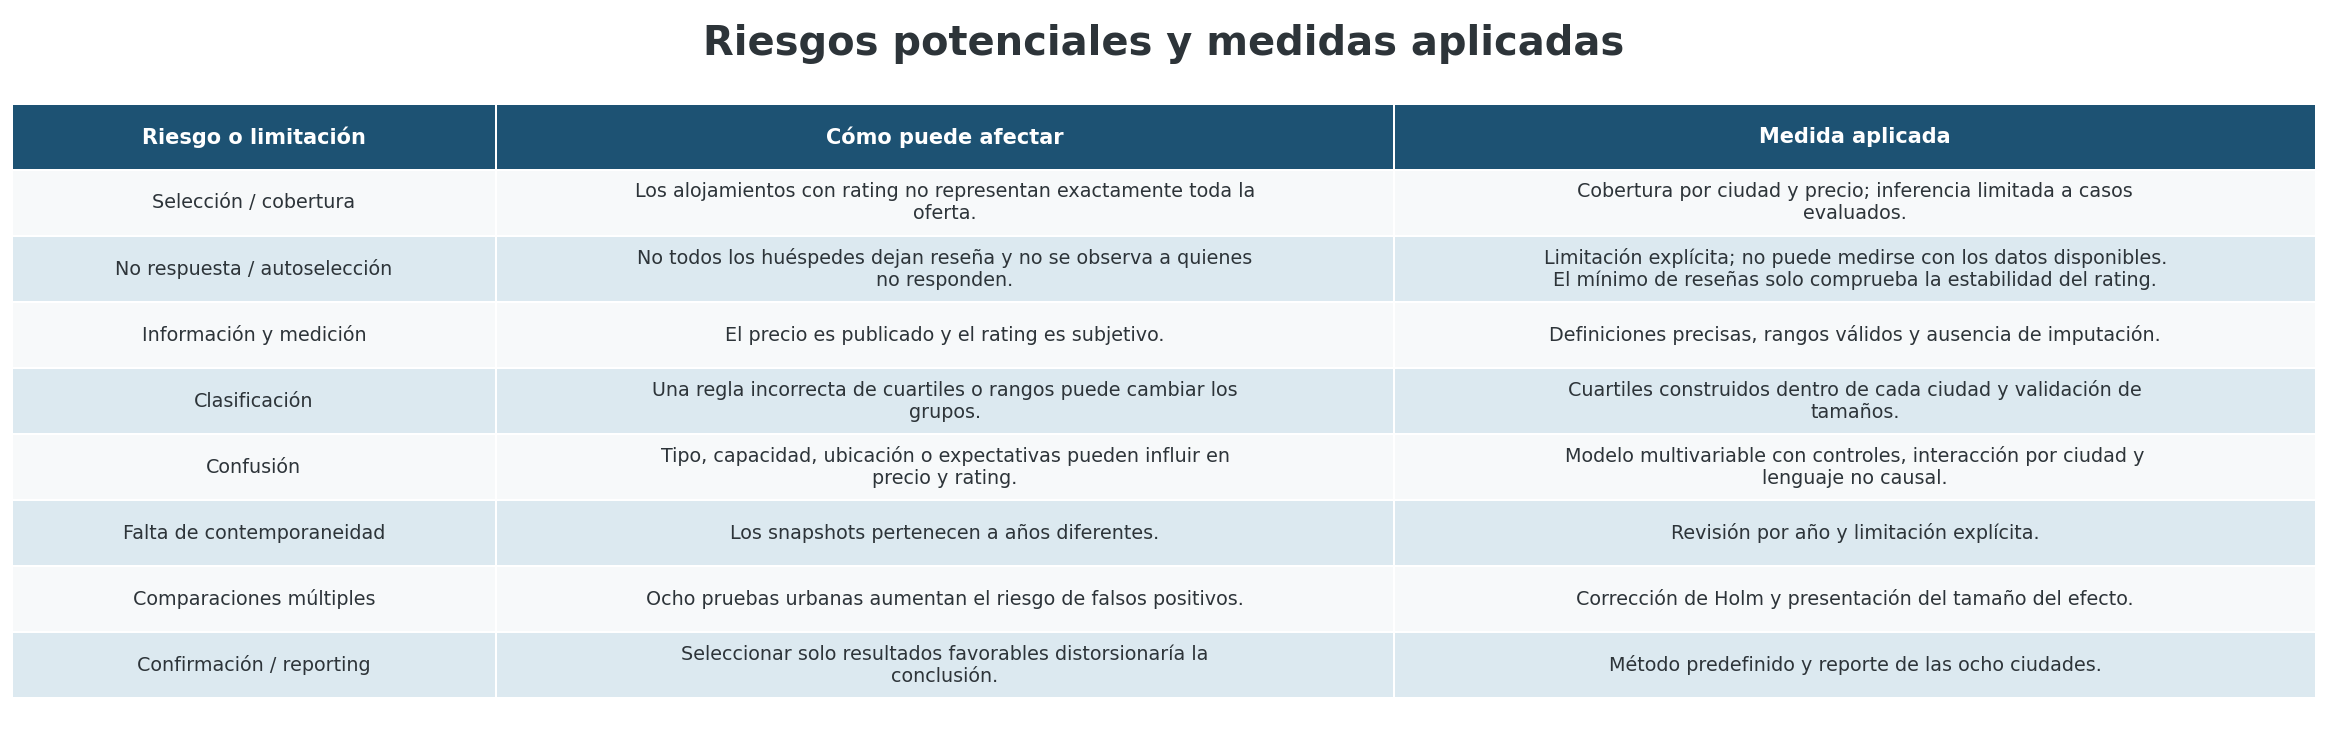

In [24]:
bias_register = pd.DataFrame(
    {
        "Riesgo o limitación": [
            "Selección / cobertura",
            "No respuesta / autoselección",
            "Información y medición",
            "Clasificación",
            "Confusión",
            "Falta de contemporaneidad",
            "Comparaciones múltiples",
            "Confirmación / reporting",
        ],
        "Cómo puede afectar": [
            "Los alojamientos con rating no representan exactamente toda la oferta.",
            "No todos los huéspedes dejan reseña y no se observa a quienes no responden.",
            "El precio es publicado y el rating es subjetivo.",
            "Una regla incorrecta de cuartiles o rangos puede cambiar los grupos.",
            "Tipo, capacidad, ubicación o expectativas pueden influir en precio y rating.",
            "Los snapshots pertenecen a años diferentes.",
            "Ocho pruebas urbanas aumentan el riesgo de falsos positivos.",
            "Seleccionar solo resultados favorables distorsionaría la conclusión.",
        ],
        "Medida aplicada": [
            "Cobertura por ciudad y precio; inferencia limitada a casos evaluados.",
            "Limitación explícita; no puede medirse con los datos disponibles. El mínimo de reseñas solo comprueba la estabilidad del rating.",
            "Definiciones precisas, rangos válidos y ausencia de imputación.",
            "Cuartiles construidos dentro de cada ciudad y validación de tamaños.",
            "Modelo multivariable con controles, interacción por ciudad y lenguaje no causal.",
            "Revisión por año y limitación explícita.",
            "Corrección de Holm y presentación del tamaño del efecto.",
            "Método predefinido y reporte de las ocho ciudades.",
        ],
    }
)

bias_table = bias_register.copy()
wrap_widths = {
    "Riesgo o limitación": 28,
    "Cómo puede afectar": 62,
    "Medida aplicada": 66,
}
for column, width in wrap_widths.items():
    bias_table[column] = bias_table[column].map(
        lambda text: textwrap.fill(str(text), width=width)
    )

graphic_table(
    bias_table,
    "Riesgos potenciales y medidas aplicadas",width=20,font_size=11.5,column_widths=[0.21, 0.39, 0.40],
)

### Interpretación

Los principales riesgos son la cobertura desigual, la autoselección de quienes dejan reseña, el uso de precios publicados y la falta de contemporaneidad perfecta.

El modelo reduce parte de la confusión asociada con las **variables observadas incluidas**: ciudad, tipo de alojamiento, capacidad, baños, reserva instantánea y año. No elimina la confusión residual causada por factores no disponibles, como la calidad del servicio, las expectativas del cliente, la ubicación exacta o el precio realmente pagado.

Por tanto, los resultados describen asociaciones y no deben interpretarse como relaciones causales.

## 11. Respuesta y recomendación de negocio

### Respuesta a la pregunta

Existe una relación global positiva entre precio y satisfacción, pero es **muy débil** (**Spearman ρ = 0,087**). Por tanto, un alojamiento más caro no garantiza una mayor satisfacción general.

La relación bruta varía entre ciudades. Mallorca, Girona y Málaga presentan las asociaciones positivas más claras. Barcelona muestra una asociación negativa estadísticamente significativa después de la corrección por comparaciones múltiples, pero su magnitud es muy débil.

El modelo multivariable confirma que la relación ajustada también cambia entre ciudades. Tras controlar por tipo de alojamiento, capacidad, baños, reserva instantánea y año, se mantienen asociaciones positivas estadísticamente significativas en **Girona (+0,27 puntos)**, **Mallorca (+0,24)**, **Málaga (+0,20)** y **Madrid (+0,17)** ante un aumento del 10 % del precio. Barcelona no presenta una asociación ajustada concluyente.

La prueba de robustez mantiene la dirección del efecto en las ocho ciudades al controlar adicionalmente por el volumen de reseñas. El cambio máximo entre ambos modelos es de solo **0,078 puntos**, aunque la capacidad explicativa continúa siendo limitada: el R² aumenta de **0,035** a **0,059**.

En conjunto, el patrón es estadísticamente estable, pero pequeño desde el punto de vista práctico. El precio y las variables disponibles explican únicamente una parte reducida de la satisfacción.

### Recomendación

- Evitar una estrategia uniforme y contextualizar el pricing por ciudad, sin utilizar el precio como una palanca directa de satisfacción.
- Complementar las decisiones de pricing con indicadores reales de experiencia, calidad del servicio y, si estuviera disponible, el contenido de las reseñas.
- Priorizar mejoras operativas y de servicio antes que aumentos de precio orientados únicamente a elevar la percepción de calidad.
- Interpretar Mallorca, Girona y Menorca con mayor cautela debido a su menor cobertura y, en el caso de Menorca, al tamaño reducido de la muestra.

## 12. Alcance de la conclusión

- Los resultados representan alojamientos con precio positivo y rating disponible en las ocho ciudades analizadas.
- Los análisis describen asociaciones y no demuestran causalidad.
- La menor cobertura de Mallorca y Girona, la concentración de ratings altos y el uso de snapshots de distintos años limitan la generalización.
- Las decisiones deben considerar la magnitud de los efectos, la cobertura y el contexto de cada ciudad.